In [1]:
! pip install -U openpyxl pyarrow pandas


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

# [Skip for evaluation analysis] Transforming benchmark1 for evaluation

In [3]:
real_df = pd.read_excel("../geoca_real_eval.xlsx", sheet_name=None)
real_df

{'Adminstrative':                                                query  \
 0  Where can I find information on the legislativ...   
 1  Where can I find data on Canada's federal elec...   
 2   the names and locations of First Nations thro...   
 3  What dataset includes the digital representati...   
 4  How can I find information about the Rouge Nat...   
 
                                    related documents  
 0  National Parks and National Park Reserves of C...  
 1  Administrative and Electoral Boundaries of Can...  
 2                                                NaN  
 3                                                NaN  
 4  National Parks and National Park Reserves of C...  ,
 'Economy':                                                query  \
 0  2015 Canadian household income by census subdi...   
 1  Indigenous Services Canada infrastructure inve...   
 2        List of natural resource projects in Canada   
 3  Map of Canada's current indigenous mining proj...   
 4  Ca

In [4]:
df_list = []
for key, val in real_df.items():
    df = real_df[key]
    df['geo_theme'] = key
    df_list.append(df)

full_df = pd.concat(df_list).reset_index()
full_df

,index,query,related documents,geo_theme
0,0,Where can I find information on the legislativ...,National Parks and National Park Reserves of C...,Adminstrative
1,1,Where can I find data on Canada's federal elec...,Administrative and Electoral Boundaries of Can...,Adminstrative
2,2,the names and locations of First Nations thro...,NaN,Adminstrative
3,3,What dataset includes the digital representati...,NaN,Adminstrative
4,4,How can I find information about the Rouge Nat...,National Parks and National Park Reserves of C...,Adminstrative
...,...,...,...,...
77,4,flu spread monitoring,NaN,Society
78,5,flu-like illness tracking map,NaN,Society
79,6,COVID-19 cases and deaths by region,NaN,Society
80,7,Which languages are most commonly spoken in di...,NaN,Society


In [5]:
full_df[~full_df['related documents'].isna()]

,index,query,related documents,geo_theme
0,0,Where can I find information on the legislativ...,National Parks and National Park Reserves of C...,Adminstrative
1,1,Where can I find data on Canada's federal elec...,Administrative and Electoral Boundaries of Can...,Adminstrative
4,4,How can I find information about the Rouge Nat...,National Parks and National Park Reserves of C...,Adminstrative
5,0,2015 Canadian household income by census subdi...,Median total income of households in 2015 (dol...,Economy
6,1,Indigenous Services Canada infrastructure inve...,Targeted Investments in First Nations Communit...,Economy
7,2,List of natural resource projects in Canada,Major Natural Resource Projects in Canada,Economy
8,3,Map of Canada's current indigenous mining proj...,Indigenous Mining Agreements (Active),Economy
9,4,Canadian clean power generation types and capa...,Clean power generating stations by type in meg...,Economy
10,5,Map of OLES-funded essential skills projects C...,Essential Skills Training Projects,Economy
11,6,Employment and Social Development Canada skill...,Essential Skills Training Projects,Economy


- Match titles of related documents with document entries
- Compute recall@3 for current model vs best model
- save results

```
scp -J sve000@inter-nrcan-lp-gccloud.science.gc.ca ../geoca_real_eval.xlsx sve000@inter-nrcan-ubuntu2204.science.gc.ca:/space/partner/nrcan/geobase/work/oatt/dev/semanticsearch/data/benchmark/by_geo_theme/query2title.xlsx
```

# Evaluating on test split

```
scp -J <username>@<server> <username>@<server>:/space/partner/nrcan/geobase/work/oatt/dev/semanticsearch/results/finetune_via_trainer/summary_on_test.csv ./summary_on_test.csv  
```

In [8]:
!pip install matplotlib
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import numpy as np

In [10]:
df = pd.read_csv("summary_on_test.csv")
df

,level_0,Unnamed: 0,index,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,...,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100,lang,document_repr,config,model
0,0,0,0,0.320408,0.479592,0.540816,0.604082,0.320408,0.159864,0.108163,...,0.479592,0.540816,0.604082,0.458512,0.412234,0.419263,en,text_en,baseline,all-mpnet-base-v2
1,1,1,0,0.048980,0.085714,0.126531,0.177551,0.048980,0.028571,0.025306,...,0.085714,0.126531,0.177551,0.104732,0.082493,0.088636,fr,text_en,baseline,all-mpnet-base-v2
2,2,2,0,0.293878,0.451020,0.512245,0.569388,0.293878,0.150340,0.102449,...,0.451020,0.512245,0.569388,0.428891,0.384006,0.392164,en,text_seq,baseline,all-mpnet-base-v2
3,3,3,0,0.069388,0.126531,0.163265,0.204082,0.069388,0.042177,0.032653,...,0.126531,0.163265,0.204082,0.130803,0.108176,0.115269,fr,text_seq,baseline,all-mpnet-base-v2
4,4,4,0,0.281633,0.457143,0.512245,0.583673,0.281633,0.152381,0.102449,...,0.457143,0.512245,0.583673,0.430047,0.380986,0.388057,en,text_para,baseline,all-mpnet-base-v2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,19,1,0,0.300000,0.473469,0.536735,0.618367,0.300000,0.157823,0.107347,...,0.473469,0.536735,0.618367,0.452595,0.400428,0.407086,fr,text_en,finetune-mnrl-mix-para-sq1024b16ms1024,gte-multilingual-base
104,20,2,0,0.406122,0.563265,0.614286,0.697959,0.406122,0.187755,0.122857,...,0.563265,0.614286,0.697959,0.546903,0.499354,0.505397,en,text_seq,finetune-mnrl-mix-para-sq1024b16ms1024,gte-multilingual-base
105,21,3,0,0.353061,0.528571,0.575510,0.644898,0.353061,0.176190,0.115102,...,0.528571,0.575510,0.644898,0.499428,0.452886,0.459482,fr,text_seq,finetune-mnrl-mix-para-sq1024b16ms1024,gte-multilingual-base
106,22,4,0,0.410204,0.563265,0.626531,0.687755,0.410204,0.187755,0.125306,...,0.563265,0.626531,0.687755,0.545905,0.500750,0.507956,en,text_para,finetune-mnrl-mix-para-sq1024b16ms1024,gte-multilingual-base


In [11]:
df = df.drop(columns=["level_0", "Unnamed: 0", "index"])
df.shape

(108, 19)

In [12]:
df.head()

,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,cosine_precision@10,cosine_recall@1,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100,lang,document_repr,config,model
0,0.320408,0.479592,0.540816,0.604082,0.320408,0.159864,0.108163,0.060408,0.320408,0.479592,0.540816,0.604082,0.458512,0.412234,0.419263,en,text_en,baseline,all-mpnet-base-v2
1,0.048980,0.085714,0.126531,0.177551,0.048980,0.028571,0.025306,0.017755,0.048980,0.085714,0.126531,0.177551,0.104732,0.082493,0.088636,fr,text_en,baseline,all-mpnet-base-v2
2,0.293878,0.451020,0.512245,0.569388,0.293878,0.150340,0.102449,0.056939,0.293878,0.451020,0.512245,0.569388,0.428891,0.384006,0.392164,en,text_seq,baseline,all-mpnet-base-v2
3,0.069388,0.126531,0.163265,0.204082,0.069388,0.042177,0.032653,0.020408,0.069388,0.126531,0.163265,0.204082,0.130803,0.108176,0.115269,fr,text_seq,baseline,all-mpnet-base-v2
4,0.281633,0.457143,0.512245,0.583673,0.281633,0.152381,0.102449,0.058367,0.281633,0.457143,0.512245,0.583673,0.430047,0.380986,0.388057,en,text_para,baseline,all-mpnet-base-v2


In [13]:
df["full_name"] = df["model"] +"-"+ df["document_repr"]+ "-"+ df["config"]
df.head()

,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,cosine_precision@10,cosine_recall@1,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100,lang,document_repr,config,model,full_name
0,0.320408,0.479592,0.540816,0.604082,0.320408,0.159864,0.108163,0.060408,0.320408,0.479592,0.540816,0.604082,0.458512,0.412234,0.419263,en,text_en,baseline,all-mpnet-base-v2,all-mpnet-base-v2-text_en-baseline
1,0.048980,0.085714,0.126531,0.177551,0.048980,0.028571,0.025306,0.017755,0.048980,0.085714,0.126531,0.177551,0.104732,0.082493,0.088636,fr,text_en,baseline,all-mpnet-base-v2,all-mpnet-base-v2-text_en-baseline
2,0.293878,0.451020,0.512245,0.569388,0.293878,0.150340,0.102449,0.056939,0.293878,0.451020,0.512245,0.569388,0.428891,0.384006,0.392164,en,text_seq,baseline,all-mpnet-base-v2,all-mpnet-base-v2-text_seq-baseline
3,0.069388,0.126531,0.163265,0.204082,0.069388,0.042177,0.032653,0.020408,0.069388,0.126531,0.163265,0.204082,0.130803,0.108176,0.115269,fr,text_seq,baseline,all-mpnet-base-v2,all-mpnet-base-v2-text_seq-baseline
4,0.281633,0.457143,0.512245,0.583673,0.281633,0.152381,0.102449,0.058367,0.281633,0.457143,0.512245,0.583673,0.430047,0.380986,0.388057,en,text_para,baseline,all-mpnet-base-v2,all-mpnet-base-v2-text_para-baseline


In [14]:
# best model for pure EN performance
subset_df = df[(df["document_repr"]=="text_en") & 
               (df["lang"]=="en")]
subset_df.sort_values(by="cosine_recall@3", ascending=False).head()

,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,cosine_precision@10,cosine_recall@1,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100,lang,document_repr,config,model,full_name
96,0.406122,0.579592,0.628571,0.700000,0.406122,0.193197,0.125714,0.070000,0.406122,0.579592,0.628571,0.700000,0.550631,0.503235,0.509486,en,text_en,finetune-mnrl-mix-seq-sq512,gte-multilingual-base,gte-multilingual-base-text_en-finetune-mnrl-mi...
102,0.410204,0.575510,0.618367,0.702041,0.410204,0.191837,0.123673,0.070204,0.410204,0.575510,0.618367,0.702041,0.553204,0.506055,0.511913,en,text_en,finetune-mnrl-mix-para-sq1024b16ms1024,gte-multilingual-base,gte-multilingual-base-text_en-finetune-mnrl-mi...
6,0.391837,0.571429,0.618367,0.702041,0.391837,0.190476,0.123673,0.070204,0.391837,0.571429,0.618367,0.702041,0.543522,0.493190,0.498124,en,text_en,finetune-mnrl-sq512ms2048,all-mpnet-base-v2,all-mpnet-base-v2-text_en-finetune-mnrl-sq512m...
78,0.397959,0.567347,0.618367,0.693878,0.397959,0.189116,0.123673,0.069388,0.397959,0.567347,0.618367,0.693878,0.544472,0.496976,0.502888,en,text_en,finetune-mnrl-sq512ms2048,gte-base-en-v1.5,gte-base-en-v1.5-text_en-finetune-mnrl-sq512ms...
42,0.393878,0.559184,0.618367,0.693878,0.393878,0.186395,0.123673,0.069388,0.393878,0.559184,0.618367,0.693878,0.540156,0.491497,0.497475,en,text_en,finetune-mnrl-sq512ms2048,all-MiniLM-L12-v2,all-MiniLM-L12-v2-text_en-finetune-mnrl-sq512m...


In [16]:
# Side quest: checking best models performance from ^ on French data
subset_df = df[(df["document_repr"]=="text_en") & 
               (df["lang"]=="fr") & (df["model"]=="gte-multilingual-base")]
subset_df

,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,cosine_precision@10,cosine_recall@1,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100,lang,document_repr,config,model,full_name
85,0.230612,0.385714,0.457143,0.526531,0.230612,0.128571,0.091429,0.052653,0.230612,0.385714,0.457143,0.526531,0.372366,0.323567,0.332417,fr,text_en,baseline,gte-multilingual-base,gte-multilingual-base-text_en-baseline
91,0.269388,0.446939,0.495918,0.589796,0.269388,0.148980,0.099184,0.058980,0.269388,0.446939,0.495918,0.589796,0.423368,0.370944,0.377644,fr,text_en,finetune-mnrl-sq512ms2048,gte-multilingual-base,gte-multilingual-base-text_en-finetune-mnrl-sq...
97,0.316327,0.479592,0.544898,0.630612,0.316327,0.159864,0.108980,0.063061,0.316327,0.479592,0.544898,0.630612,0.467463,0.416164,0.422781,fr,text_en,finetune-mnrl-mix-seq-sq512,gte-multilingual-base,gte-multilingual-base-text_en-finetune-mnrl-mi...
103,0.300000,0.473469,0.536735,0.618367,0.300000,0.157823,0.107347,0.061837,0.300000,0.473469,0.536735,0.618367,0.452595,0.400428,0.407086,fr,text_en,finetune-mnrl-mix-para-sq1024b16ms1024,gte-multilingual-base,gte-multilingual-base-text_en-finetune-mnrl-mi...


In [17]:
# best model for FR performance
subset_df = df[(df["document_repr"]=="text_seq") & 
               (df["lang"]=="fr")]
subset_df.sort_values(by="cosine_recall@3", ascending=False).head()

,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,cosine_precision@10,cosine_recall@1,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100,lang,document_repr,config,model,full_name
105,0.353061,0.528571,0.575510,0.644898,0.353061,0.176190,0.115102,0.064490,0.353061,0.528571,0.575510,0.644898,0.499428,0.452886,0.459482,fr,text_seq,finetune-mnrl-mix-para-sq1024b16ms1024,gte-multilingual-base,gte-multilingual-base-text_seq-finetune-mnrl-m...
99,0.371429,0.526531,0.575510,0.651020,0.371429,0.175510,0.115102,0.065102,0.371429,0.526531,0.575510,0.651020,0.507229,0.461729,0.468041,fr,text_seq,finetune-mnrl-mix-seq-sq512,gte-multilingual-base,gte-multilingual-base-text_seq-finetune-mnrl-m...
93,0.326531,0.489796,0.536735,0.616327,0.326531,0.163265,0.107347,0.061633,0.326531,0.489796,0.536735,0.616327,0.467008,0.419664,0.425985,fr,text_seq,finetune-mnrl-sq512ms2048,gte-multilingual-base,gte-multilingual-base-text_seq-finetune-mnrl-s...
27,0.287755,0.457143,0.508163,0.583673,0.287755,0.152381,0.101633,0.058367,0.287755,0.457143,0.508163,0.583673,0.432487,0.384472,0.393094,fr,text_seq,finetune-mnrl-mix-seq,paraphrase-multilingual-mpnet-base-v2,paraphrase-multilingual-mpnet-base-v2-text_seq...
69,0.279592,0.446939,0.510204,0.583673,0.279592,0.148980,0.102041,0.058367,0.279592,0.446939,0.510204,0.583673,0.426930,0.377361,0.384701,fr,text_seq,finetune-mnrl-mix-para-sq512b64ms2048,paraphrase-multilingual-MiniLM-L12-v2,paraphrase-multilingual-MiniLM-L12-v2-text_seq...


Checking best EN+FR performing models (using mean):

In [20]:
subset_df = df[(df["document_repr"]=="text_seq")]
subset_df['exp_name'] = subset_df['model'] + "/"+subset_df['config'] +"/"+ subset_df['document_repr']

df_pivot = subset_df.pivot(index='exp_name', columns='lang', values='cosine_recall@3')
df_pivot = df_pivot[['en', 'fr']]

df_pivot['mean'] = df_pivot.mean(axis=1)
df_pivot.sort_values(by="mean", ascending=False)

lang,en,fr,mean
exp_name,,,
gte-multilingual-base/finetune-mnrl-mix-para-sq1024b16ms1024/text_seq,0.563265,0.528571,0.545918
gte-multilingual-base/finetune-mnrl-mix-seq-sq512/text_seq,0.561224,0.526531,0.543878
gte-multilingual-base/finetune-mnrl-sq512ms2048/text_seq,0.561224,0.489796,0.525510
paraphrase-multilingual-mpnet-base-v2/finetune-mnrl-mix-seq/text_seq,0.546939,0.457143,0.502041
paraphrase-multilingual-mpnet-base-v2/finetune-gist-mix-para/text_seq,0.528571,0.436735,0.482653
paraphrase-multilingual-MiniLM-L12-v2/finetune-mnrl-mix-para-sq512b64ms2048/text_seq,0.504082,0.446939,0.475510
paraphrase-multilingual-MiniLM-L12-v2/finetune-mnrl-mix-seq-sq512ms2048/text_seq,0.500000,0.438776,0.469388
gte-base-en-v1.5/finetune-mnrl-sq512ms2048/text_seq,0.563265,0.363265,0.463265
gte-multilingual-base/baseline/text_seq,0.500000,0.404082,0.452041


In [21]:
subset_df = df[(df["document_repr"]=="text_en")]
subset_df['exp_name'] = subset_df['model'] + "/"+subset_df['config'] +"/"+ subset_df['document_repr']

df_pivot = subset_df.pivot(index='exp_name', columns='lang', values='cosine_recall@3')
df_pivot = df_pivot[['en', 'fr']]

df_pivot['mean'] = df_pivot.mean(axis=1)
df_pivot.sort_values(by="mean", ascending=False)

lang,en,fr,mean
exp_name,,,
gte-multilingual-base/finetune-mnrl-mix-seq-sq512/text_en,0.579592,0.479592,0.529592
gte-multilingual-base/finetune-mnrl-mix-para-sq1024b16ms1024/text_en,0.575510,0.473469,0.524490
gte-multilingual-base/finetune-mnrl-sq512ms2048/text_en,0.551020,0.446939,0.498980
paraphrase-multilingual-mpnet-base-v2/finetune-mnrl-mix-seq/text_en,0.538776,0.453061,0.495918
paraphrase-multilingual-mpnet-base-v2/finetune-gist-mix-para/text_en,0.530612,0.426531,0.478571
paraphrase-multilingual-MiniLM-L12-v2/finetune-mnrl-mix-para-sq512b64ms2048/text_en,0.506122,0.410204,0.458163
paraphrase-multilingual-MiniLM-L12-v2/finetune-mnrl-mix-seq-sq512ms2048/text_en,0.508163,0.402041,0.455102
paraphrase-multilingual-mpnet-base-v2/finetune-mnrl/text_en,0.524490,0.385714,0.455102
gte-multilingual-base/baseline/text_en,0.520408,0.385714,0.453061


## Monolingual models
Objective: determine what monolingual model achieves best performance on EN queries with EN document representation

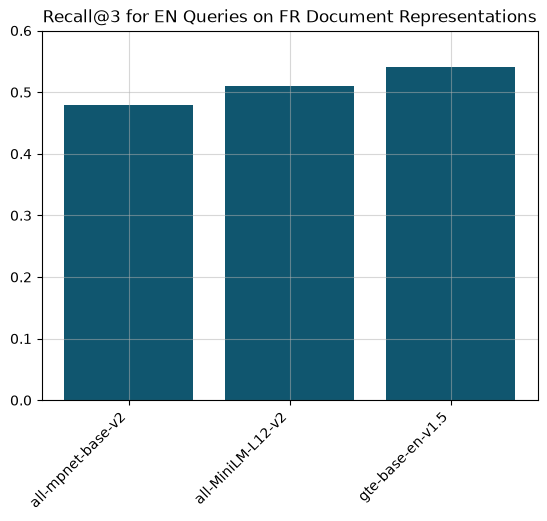

In [22]:
# Comparison of baseline monolingual models via recall@3 on EN queries and EN docs
monolingual_models = ["all-mpnet-base-v2", "all-MiniLM-L12-v2", "gte-base-en-v1.5"]

subset_df = df[(df["config"]=="baseline") & 
               (df["document_repr"]=="text_en") & 
               (df["lang"]=="en") &
               (df["model"].isin(monolingual_models))]

plt.bar(subset_df["model"], subset_df["cosine_recall@3"], color="#10566f")
plt.xticks(rotation=45, ha="right")
plt.title(f"Recall@3 for EN Queries on FR Document Representations")
plt.grid(True, alpha=0.5)
plt.ylim(0.0, 0.6)
plt.show()

- GTE does best overall
- But performance is very similar ~50%

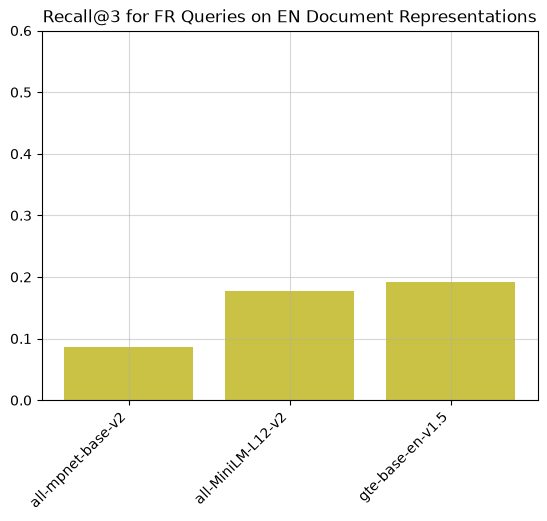

In [23]:
# Extra: How do these models do for French models? (via recall@3 on FR queries and EN docs)
subset_df = df[(df["config"]=="baseline") & 
               (df["document_repr"]=="text_en") & 
               (df["lang"]=="fr") &
               (df["model"].isin(monolingual_models))]

plt.bar(subset_df["model"], subset_df["cosine_recall@3"], color="#cac244")
plt.xticks(rotation=45, ha="right")
plt.title(f"Recall@3 for FR Queries on EN Document Representations")
plt.ylim(0.0, 0.6)
plt.grid(True, alpha=0.5)
plt.show()

- Baseline performance on FR queries is <20%
- mpnet in particular does worst at ~8%
- GTE is also best

C:\Users\sesina\AppData\Local\Temp\ipykernel_20192\3853376964.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_base = subset_df[(df["config"] == "baseline")]
C:\Users\sesina\AppData\Local\Temp\ipykernel_20192\3853376964.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ft  = subset_df[(~(df["config"] == "baseline"))]


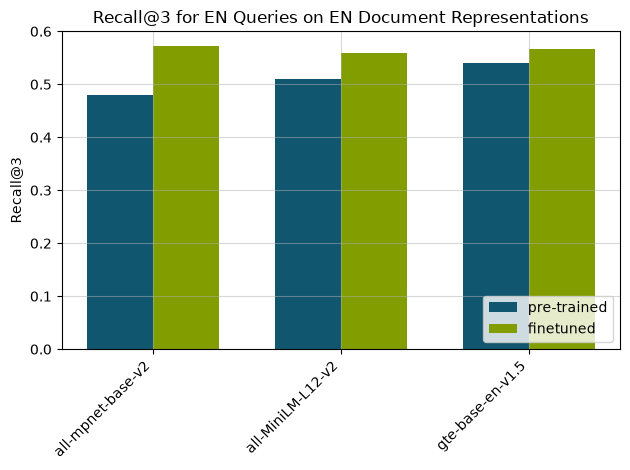

In [24]:
# Does finetuning help improve performance on EN queries and EN docs?
subset_df = df[(df["document_repr"]=="text_en") & 
               (df["lang"]=="en") &
               (df["model"].isin(monolingual_models))]

df_base = subset_df[(df["config"] == "baseline")]
df_ft  = subset_df[(~(df["config"] == "baseline"))]

df_base = df_base.set_index("model").loc[monolingual_models]
df_ft  = df_ft.set_index("model").loc[monolingual_models]

x = np.arange(len(monolingual_models))  # positions
width = 0.35

plt.bar(x - width/2, df_base["cosine_recall@3"], width, label="pre-trained", color="#10566f")
plt.bar(x + width/2, df_ft["cosine_recall@3"], width, label="finetuned", color="#819d00")

plt.xticks(x, monolingual_models, rotation=45, ha="right")
plt.ylabel("Recall@3")
plt.title("Recall@3 for EN Queries on EN Document Representations")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

- Finetuning imrpoves performance.
- Best improvement observed in mpnet, achieves highest score
- Overall performance for all models becomes VERY close, ~55%

C:\Users\sesina\AppData\Local\Temp\ipykernel_20192\2978409915.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_base = subset_df[(df["config"] == "baseline")]
C:\Users\sesina\AppData\Local\Temp\ipykernel_20192\2978409915.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ft  = subset_df[(~(df["config"] == "baseline"))]


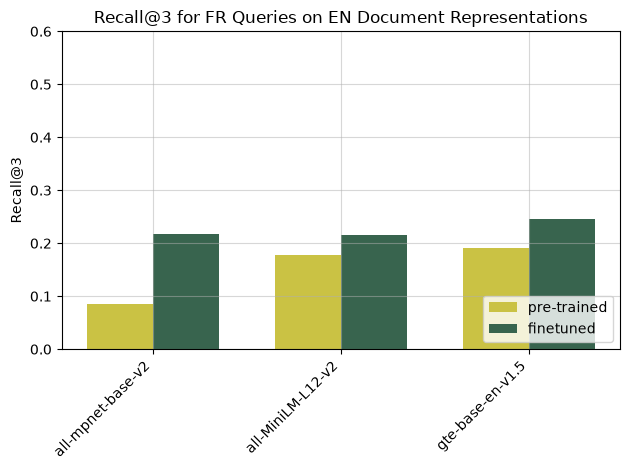

In [25]:
# Extra: Any side-effects on performance via FR queries?
subset_df = df[(df["document_repr"]=="text_en") & 
               (df["lang"]=="fr") &
               (df["model"].isin(monolingual_models))]

df_base = subset_df[(df["config"] == "baseline")]
df_ft  = subset_df[(~(df["config"] == "baseline"))]

df_base = df_base.set_index("model").loc[monolingual_models]
df_ft  = df_ft.set_index("model").loc[monolingual_models]

x = np.arange(len(monolingual_models))  # positions
width = 0.35

plt.bar(x - width/2, df_base["cosine_recall@3"], width, label="pre-trained", color="#cac244")
plt.bar(x + width/2, df_ft["cosine_recall@3"], width, label="finetuned", color="#38644e")

plt.xticks(x, monolingual_models, rotation=45, ha="right")
plt.ylabel("Recall@3")
plt.title("Recall@3 for FR Queries on EN Document Representations")
plt.legend(loc="lower right")
plt.ylim(0.0, 0.6)
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

- as side-effect performance on FR queries increases even if the finetuning was only done on EN queries and docs. Mostly likely due to linguistic similarities between the two languages
- mpnet shows the most improvement by achieving performance comparable to other models
- gte is still performing best on fr

---
- performance of fr is still under 25% compared to the english 50%

In [26]:
# do any ft-on-en multilingual models outperform the monolingual models on EN queries/EN docs
multilingual_models = ["paraphrase-multilingual-mpnet-base-v2", "paraphrase-multilingual-MiniLM-L12-v2", "gte-multilingual-base"]

subset_mono_df = df[(df["document_repr"]=="text_en") & 
               (df["lang"]=="en") &
               (df["model"].isin(monolingual_models)) &
               ((~(df["config"] == "baseline")))]

subset_multi_df = df[(df["document_repr"]=="text_en") & 
               (df["lang"]=="en") &
               (df["model"].isin(multilingual_models)) &
               ((df["config"] == "baseline") | (~ df["config"].str.contains("mix")))]

subset_df = pd.concat([subset_mono_df, subset_multi_df])
subset_df['model_short'] = subset_df['model'].map(lambda x: ('mpnet' if 'mpnet' in x.lower() else 'minilm' if 'minilm' in x.lower() else 'gte') + ('_multi' if 'multi' in x.lower() else ''))
subset_df['config_short'] = subset_df['config'].map(lambda x: 'baseline' if 'baseline' in x.lower() else 'ft')
subset_df['exp_name'] = subset_df['model_short']+"_"+subset_df['config_short']

subset_df = subset_df.sort_values('exp_name', ascending=True)
subset_df[['exp_name', 'model', 'model_short', 'config', 'lang', 'document_repr', 'cosine_recall@3']]



,exp_name,model,model_short,config,lang,document_repr,cosine_recall@3
78,gte_ft,gte-base-en-v1.5,gte,finetune-mnrl-sq512ms2048,en,text_en,0.567347
84,gte_multi_baseline,gte-multilingual-base,gte_multi,baseline,en,text_en,0.520408
90,gte_multi_ft,gte-multilingual-base,gte_multi,finetune-mnrl-sq512ms2048,en,text_en,0.551020
42,minilm_ft,all-MiniLM-L12-v2,minilm,finetune-mnrl-sq512ms2048,en,text_en,0.559184
48,minilm_multi_baseline,paraphrase-multilingual-MiniLM-L12-v2,minilm_multi,baseline,en,text_en,0.348980
54,minilm_multi_ft,paraphrase-multilingual-MiniLM-L12-v2,minilm_multi,finetune-mnrl-en-sq512ms2048,en,text_en,0.504082
6,mpnet_ft,all-mpnet-base-v2,mpnet,finetune-mnrl-sq512ms2048,en,text_en,0.571429
12,mpnet_multi_baseline,paraphrase-multilingual-mpnet-base-v2,mpnet_multi,baseline,en,text_en,0.402041
18,mpnet_multi_ft,paraphrase-multilingual-mpnet-base-v2,mpnet_multi,finetune-mnrl,en,text_en,0.524490


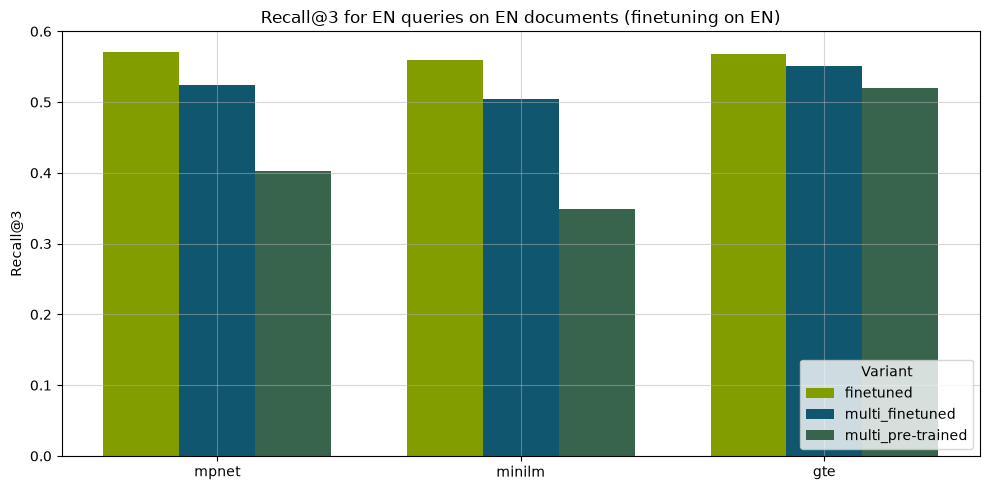

In [27]:
subset_df[["family", "variant1", "variant2"]] = subset_df["exp_name"].str.split("_", expand=True)
subset_df["variant"] = subset_df[["variant1", "variant2"]].fillna("").agg("_".join, axis=1).str.strip("_")

subset_df["variant"] = subset_df["variant"].replace({"baseline": "pre-trained", "ft": "finetuned", 'multi_baseline': "multi_pre-trained", 'multi_ft': "multi_finetuned"})

colours = ['#819d00', '#10566f', '#38644e']

pivot_df = subset_df.pivot(index="family", columns="variant", values="cosine_recall@3")
pivot_df = pivot_df.iloc[::-1]

families = pivot_df.index.tolist()
variants = pivot_df.columns.tolist()

x = np.arange(len(families))
width = 0.25  # bar width

plt.figure(figsize=(10, 5))

for i, variant in enumerate(variants):
    plt.bar(x + i * width, pivot_df[variant], width, label=variant, color=colours[i])

# Center x-ticks
plt.xticks(x + width * (len(variants) - 1) / 2, families)

plt.ylabel("Recall@3")
plt.legend(title="Variant", loc='lower right')
plt.grid(True, alpha=0.5)
plt.title("Recall@3 for EN queries on EN documents (finetuning on EN)") #ft is finetuned on English representations

plt.tight_layout()
plt.show()

In [28]:
# look at exact values
pivot_df

variant,finetuned,multi_finetuned,multi_pre-trained
family,,,
mpnet,0.571429,0.524490,0.402041
minilm,0.559184,0.504082,0.348980
gte,0.567347,0.551020,0.520408


- all multilingual model performance suffers (max 10%) compared to the monolingual fine-tuned performance
- multilingual finetuned performs better than multilingual baseline
- gte is closest in performance between the 3 variants
- finetuned monolingual mpnet is still best

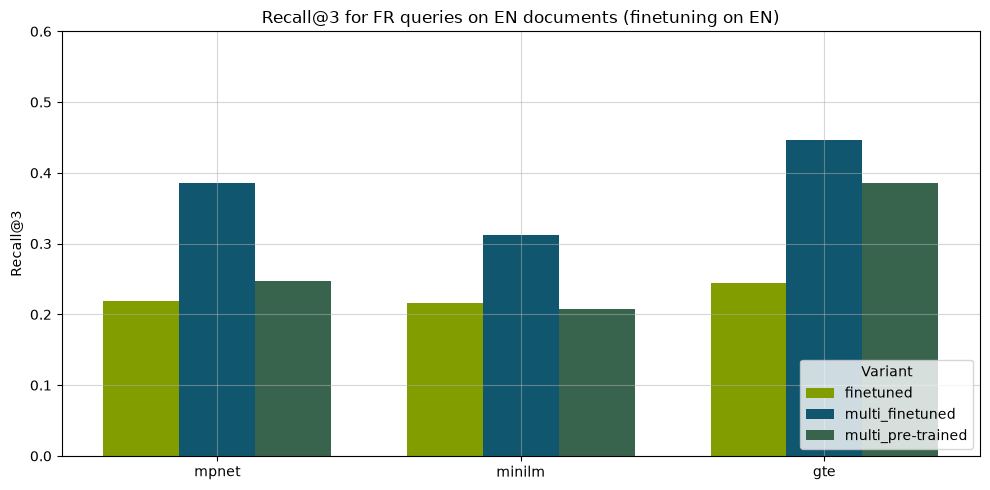

In [29]:
# any side-effects for ft multilingual models on fr queries?
multilingual_models = ["paraphrase-multilingual-mpnet-base-v2", "paraphrase-multilingual-MiniLM-L12-v2", "gte-multilingual-base"]

subset_mono_df = df[(df["document_repr"]=="text_en") & 
               (df["lang"]=="fr") &
               (df["model"].isin(monolingual_models)) &
               ((~(df["config"] == "baseline")))]

subset_multi_df = df[(df["document_repr"]=="text_en") & 
               (df["lang"]=="fr") &
               (df["model"].isin(multilingual_models)) &
               ((df["config"] == "baseline") | (~ df["config"].str.contains("mix")))]

subset_df = pd.concat([subset_mono_df, subset_multi_df])
subset_df['model_short'] = subset_df['model'].map(lambda x: ('mpnet' if 'mpnet' in x.lower() else 'minilm' if 'minilm' in x.lower() else 'gte') + ('_multi' if 'multi' in x.lower() else ''))
subset_df['config_short'] = subset_df['config'].map(lambda x: 'baseline' if 'baseline' in x.lower() else 'ft')
subset_df['exp_name'] = subset_df['model_short']+"_"+subset_df['config_short']

subset_df = subset_df.sort_values('exp_name', ascending=True)
subset_df[["family", "variant1", "variant2"]] = subset_df["exp_name"].str.split("_", expand=True)
subset_df["variant"] = subset_df[["variant1", "variant2"]].fillna("").agg("_".join, axis=1).str.strip("_")

subset_df["variant"] = subset_df["variant"].replace({"baseline": "pre-trained", "ft": "finetuned", 'multi_baseline': "multi_pre-trained", 'multi_ft': "multi_finetuned"})

pivot_df = subset_df.pivot(index="family", columns="variant", values="cosine_recall@3")
pivot_df = pivot_df.iloc[::-1]

families = pivot_df.index.tolist()
variants = pivot_df.columns.tolist()

x = np.arange(len(families))
width = 0.25  # bar width

plt.figure(figsize=(10, 5))
colours = ['#819d00', '#10566f', '#38644e']

for i, variant in enumerate(variants):
    plt.bar(x + i * width, pivot_df[variant], width, label=variant, color=colours[i])

# Center x-ticks
plt.xticks(x + width * (len(variants) - 1) / 2, families)

plt.ylabel("Recall@3")
plt.legend(title="Variant", loc='lower right')
plt.grid(True, alpha=0.5)
plt.ylim(0.0, 0.6)
plt.title("Recall@3 for FR queries on EN documents (finetuning on EN)")

plt.tight_layout()
plt.show()


- Even though multi's performance does not reach mono's performance on EN queries, the side-effect of training on En-queries and EN-docs on FR performance is a lot more prominent
- FR performance reaches to around ~30-45%

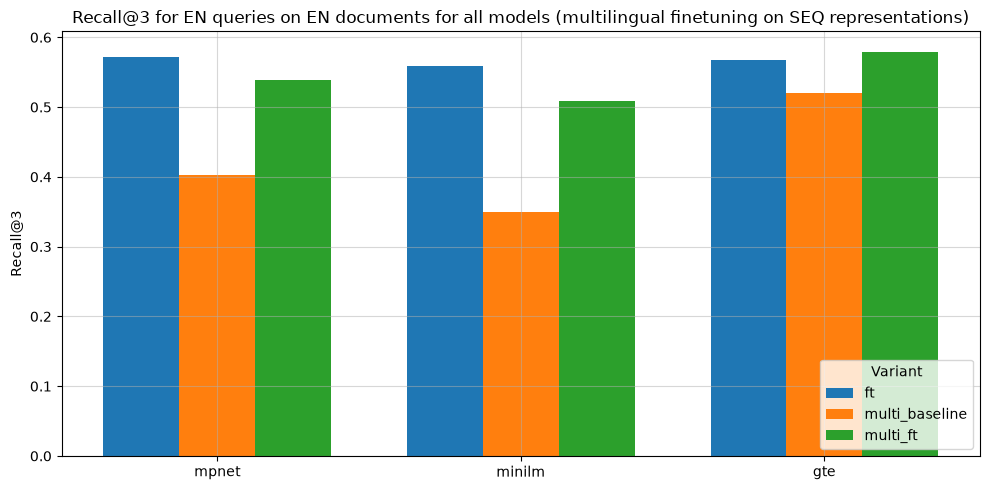

In [30]:
# do any ft-on-seq multilingual models outperform the monolingual models on EN queries/EN docs
multilingual_models = ["paraphrase-multilingual-mpnet-base-v2", "paraphrase-multilingual-MiniLM-L12-v2", "gte-multilingual-base"]

subset_mono_df = df[(df["document_repr"]=="text_en") & 
               (df["lang"]=="en") &
               (df["model"].isin(monolingual_models)) &
               ((~(df["config"] == "baseline")))]

subset_multi_df = df[(df["document_repr"]=="text_en") & 
               (df["lang"]=="en") &
               (df["model"].isin(multilingual_models)) &
               ((df["config"] == "baseline") | df["config"].str.contains("mix-seq"))]

subset_df = pd.concat([subset_mono_df, subset_multi_df])
subset_df['model_short'] = subset_df['model'].map(lambda x: ('mpnet' if 'mpnet' in x.lower() else 'minilm' if 'minilm' in x.lower() else 'gte') + ('_multi' if 'multi' in x.lower() else ''))
subset_df['config_short'] = subset_df['config'].map(lambda x: 'baseline' if 'baseline' in x.lower() else 'ft')
subset_df['exp_name'] = subset_df['model_short']+"_"+subset_df['config_short']

subset_df = subset_df.sort_values('exp_name', ascending=True)
subset_df[["family", "variant1", "variant2"]] = subset_df["exp_name"].str.split("_", expand=True)
subset_df["variant"] = subset_df[["variant1", "variant2"]].fillna("").agg("_".join, axis=1).str.strip("_")

pivot_df = subset_df.pivot(index="family", columns="variant", values="cosine_recall@3")
pivot_df = pivot_df.iloc[::-1]

families = pivot_df.index.tolist()
variants = pivot_df.columns.tolist()

x = np.arange(len(families))
width = 0.25  # bar width

plt.figure(figsize=(10, 5))

for i, variant in enumerate(variants):
    plt.bar(x + i * width, pivot_df[variant], width, label=variant)

# Center x-ticks
plt.xticks(x + width * (len(variants) - 1) / 2, families)

plt.ylabel("Recall@3")
plt.legend(title="Variant", loc='lower right')
plt.grid(True, alpha=0.5)
plt.title("Recall@3 for EN queries on EN documents for all models (multilingual finetuning on SEQ representations)")

plt.tight_layout()
plt.show()

In [31]:
# look at exact values
pivot_df

variant,ft,multi_baseline,multi_ft
family,,,
mpnet,0.571429,0.402041,0.538776
minilm,0.559184,0.348980,0.508163
gte,0.567347,0.520408,0.579592


- In mpnet and miniLM - no, but on gte, we actually see the multilingual finetuned model achieve the best performance over all.

## Multilingual models
Objective: determine what multilingual model achieves best cross-lingual performance on FR-EN queries with variable document representation

In [32]:
# how well does finetuning on seq repr help/hinder cross-lingual performance?
multilingual_models = ["paraphrase-multilingual-mpnet-base-v2", "paraphrase-multilingual-MiniLM-L12-v2", "gte-multilingual-base"]

subset_df = df[(df["document_repr"]=="text_seq") &
               (df["model"].isin(multilingual_models)) &
               
               ((df["config"] == "baseline") | (df["config"].str.contains("mix-seq")))]

subset_df['model_short'] = subset_df['model'].map(lambda x: ('mpnet' if 'mpnet' in x.lower() else 'minilm' if 'minilm' in x.lower() else 'gte') + ('_multi' if 'multi' in x.lower() else ''))
subset_df['config_short'] = subset_df['config'].map(lambda x: 'baseline' if 'baseline' in x.lower() else 'ft')
subset_df['exp_name'] = subset_df['model_short']+"_"+subset_df['config_short']

subset_df[['model', 'model_short', 'lang', 'config', 'exp_name', 'document_repr', 'cosine_recall@3']]


,model,model_short,lang,config,exp_name,document_repr,cosine_recall@3
14,paraphrase-multilingual-mpnet-base-v2,mpnet_multi,en,baseline,mpnet_multi_baseline,text_seq,0.397959
15,paraphrase-multilingual-mpnet-base-v2,mpnet_multi,fr,baseline,mpnet_multi_baseline,text_seq,0.267347
26,paraphrase-multilingual-mpnet-base-v2,mpnet_multi,en,finetune-mnrl-mix-seq,mpnet_multi_ft,text_seq,0.546939
27,paraphrase-multilingual-mpnet-base-v2,mpnet_multi,fr,finetune-mnrl-mix-seq,mpnet_multi_ft,text_seq,0.457143
50,paraphrase-multilingual-MiniLM-L12-v2,minilm_multi,en,baseline,minilm_multi_baseline,text_seq,0.355102
51,paraphrase-multilingual-MiniLM-L12-v2,minilm_multi,fr,baseline,minilm_multi_baseline,text_seq,0.218367
62,paraphrase-multilingual-MiniLM-L12-v2,minilm_multi,en,finetune-mnrl-mix-seq-sq512ms2048,minilm_multi_ft,text_seq,0.500000
63,paraphrase-multilingual-MiniLM-L12-v2,minilm_multi,fr,finetune-mnrl-mix-seq-sq512ms2048,minilm_multi_ft,text_seq,0.438776
86,gte-multilingual-base,gte_multi,en,baseline,gte_multi_baseline,text_seq,0.500000
87,gte-multilingual-base,gte_multi,fr,baseline,gte_multi_baseline,text_seq,0.404082


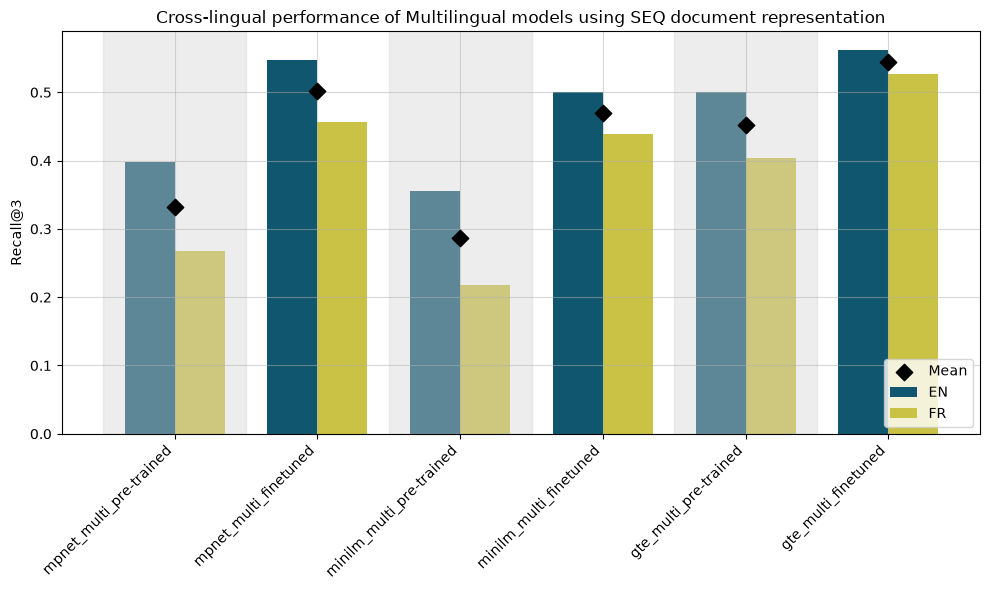

In [33]:
# Pivot
subset_df["exp_name"] = (
    subset_df["exp_name"]
    .str.replace("baseline", "pre-trained", regex=True)
    .str.replace("ft", "finetuned", regex=True)
)
df_pivot = subset_df.pivot(index='exp_name', columns='lang', values='cosine_recall@3')
df_pivot = df_pivot[['en', 'fr']]
df_pivot = df_pivot.iloc[::-1]

df_pivot['mean'] = df_pivot.mean(axis=1)

x = np.arange(len(df_pivot))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

# Plot normal bars (keep EN/FR colors)
ax.bar(x - width/2, df_pivot['en'], width, label='EN', color='#10566f')
ax.bar(x + width/2, df_pivot['fr'], width, label='FR', color='#cac244')

ax.scatter(x, df_pivot['mean'], color='black', s=70, marker='D', label='Mean', zorder=3)

for i, name in enumerate(df_pivot.index):
    if 'pre-trained' in name.lower():
        ax.axvspan(i - 0.5, i + 0.5, color='lightgray', alpha=0.4)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(df_pivot.index, rotation=45, ha='right')

ax.set_title('Cross-lingual performance of Multilingual models using SEQ document representation')
ax.set_ylabel('Recall@3')
ax.legend(loc='lower right')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


- Baseline cross-lingual performances shows higher EN performance than FR performance by ~10-15%
- FT helps improve mean performance by ~5-15%
- FT models exhibit smaller discrepancy between EN and FR performance from <5% - 10%
- FT improves performance of both EN and FR, but FR shows higher relative improvement than EN

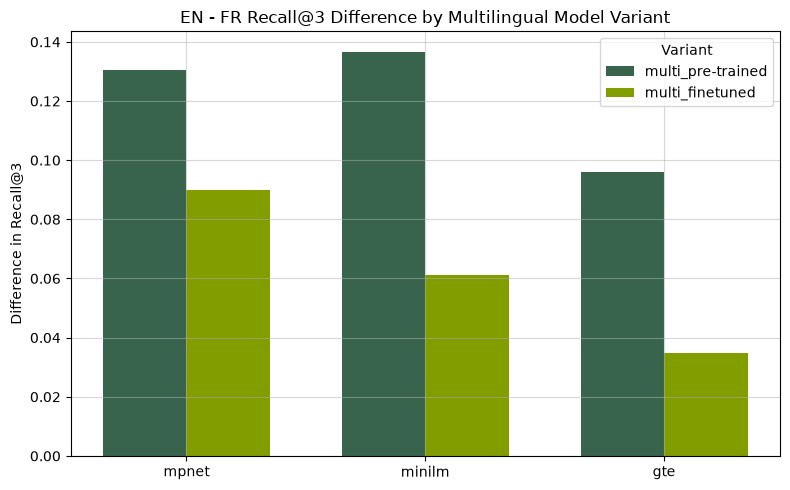

In [34]:
# Lets look into that "FT exhibit smaller discprepancy" statement a bit more clearly... graph the drop in difference
df_pivot = subset_df.pivot(index='exp_name', columns='lang', values='cosine_recall@3')

df_pivot['recall_diff_en_fr'] = df_pivot['en'] - df_pivot['fr']
df_plot = df_pivot.reset_index()

parts = df_plot["exp_name"].str.split("_", expand=True)
df_plot["family"] = parts[0]
df_plot["variant"] = parts.iloc[:, 1:].agg("_".join, axis=1)

pivot_df = df_plot.pivot(
    index="family",
    columns="variant",
    values="recall_diff_en_fr"
)
pivot_df = pivot_df.iloc[::-1]

families = pivot_df.index.tolist()
x = np.arange(len(families))
width = 0.35
variants = ["multi_pre-trained", "multi_finetuned"]
colors = ['#38644e','#819d00']

fig, ax = plt.subplots(figsize=(8, 5))
for i, variant in enumerate(variants):
    ax.bar(
        x + i * width,
        pivot_df[variant],
        width,
        label=variant,
        color=colors[i]
    )

ax.set_xticks(x + width / 2)
ax.set_xticklabels(families)

ax.set_ylabel("Difference in Recall@3")
ax.set_title("EN - FR Recall@3 Difference by Multilingual Model Variant")

ax.legend(title="Variant")
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

- Cross-lingual performance difference decreases with FT by 5% minimum, or relatively from 30-50%
- GTE cross-lingual performance difference after FT is within 5% !!

In [35]:
# what is cross-lingual performance on text_seq for models finetuned on mix-seq in comparison with mix-para
multilingual_models = ["paraphrase-multilingual-mpnet-base-v2", "paraphrase-multilingual-MiniLM-L12-v2", "gte-multilingual-base"]

subset_df = df[((df["document_repr"]=="text_seq")) &
               (df["model"].isin(multilingual_models)) &
               (df["config"].str.contains("mix"))] # only finetuned models!

subset_df['model_short'] = subset_df['model'].map(lambda x: ('mpnet' if 'mpnet' in x.lower() else 'minilm' if 'minilm' in x.lower() else 'gte') + ('_multi' if 'multi' in x.lower() else ''))
subset_df['config_short'] = subset_df['config'].map(lambda x: 'mix-seq' if 'mix-seq' in x.lower() else 'mix-para' if 'mix-para' in x.lower() else "")
subset_df['exp_name'] = subset_df['model_short']+"_"+subset_df['config_short']

subset_df[['model', 'model_short', 'lang', 'config', 'exp_name', 'document_repr', 'cosine_recall@3']]

,model,model_short,lang,config,exp_name,document_repr,cosine_recall@3
26,paraphrase-multilingual-mpnet-base-v2,mpnet_multi,en,finetune-mnrl-mix-seq,mpnet_multi_mix-seq,text_seq,0.546939
27,paraphrase-multilingual-mpnet-base-v2,mpnet_multi,fr,finetune-mnrl-mix-seq,mpnet_multi_mix-seq,text_seq,0.457143
32,paraphrase-multilingual-mpnet-base-v2,mpnet_multi,en,finetune-gist-mix-para,mpnet_multi_mix-para,text_seq,0.528571
33,paraphrase-multilingual-mpnet-base-v2,mpnet_multi,fr,finetune-gist-mix-para,mpnet_multi_mix-para,text_seq,0.436735
62,paraphrase-multilingual-MiniLM-L12-v2,minilm_multi,en,finetune-mnrl-mix-seq-sq512ms2048,minilm_multi_mix-seq,text_seq,0.500000
63,paraphrase-multilingual-MiniLM-L12-v2,minilm_multi,fr,finetune-mnrl-mix-seq-sq512ms2048,minilm_multi_mix-seq,text_seq,0.438776
68,paraphrase-multilingual-MiniLM-L12-v2,minilm_multi,en,finetune-mnrl-mix-para-sq512b64ms2048,minilm_multi_mix-para,text_seq,0.504082
69,paraphrase-multilingual-MiniLM-L12-v2,minilm_multi,fr,finetune-mnrl-mix-para-sq512b64ms2048,minilm_multi_mix-para,text_seq,0.446939
98,gte-multilingual-base,gte_multi,en,finetune-mnrl-mix-seq-sq512,gte_multi_mix-seq,text_seq,0.561224
99,gte-multilingual-base,gte_multi,fr,finetune-mnrl-mix-seq-sq512,gte_multi_mix-seq,text_seq,0.526531


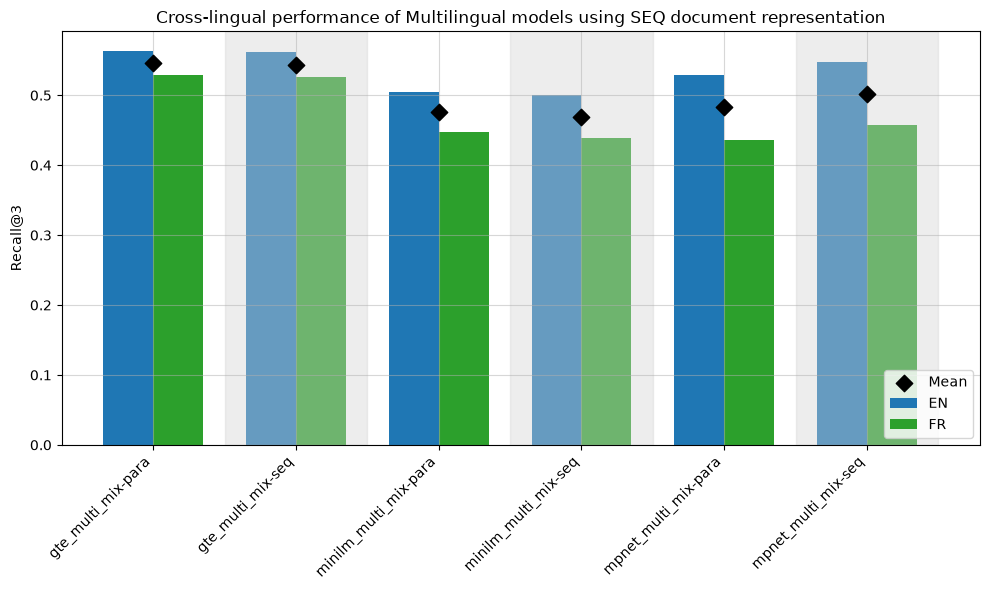

In [36]:
# Pivot
df_pivot = subset_df.pivot(index='exp_name', columns='lang', values='cosine_recall@3')
df_pivot = df_pivot[['en', 'fr']]

df_pivot['mean'] = df_pivot.mean(axis=1)

x = np.arange(len(df_pivot))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

# Plot normal bars (keep EN/FR colors)
ax.bar(x - width/2, df_pivot['en'], width, label='EN', color='tab:blue')
ax.bar(x + width/2, df_pivot['fr'], width, label='FR', color='tab:green')

ax.scatter(x, df_pivot['mean'], color='black', s=70, marker='D', label='Mean', zorder=3)

for i, name in enumerate(df_pivot.index):
    if 'seq' in name.lower():
        ax.axvspan(i - 0.5, i + 0.5, color='lightgray', alpha=0.4)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(df_pivot.index, rotation=45, ha='right')

ax.set_title('Cross-lingual performance of Multilingual models using SEQ document representation')
ax.set_ylabel('Recall@3')
ax.legend(loc='lower right')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

- generally performance is ever so slightly higher on text-seq when models are fine-tuned on text-para...

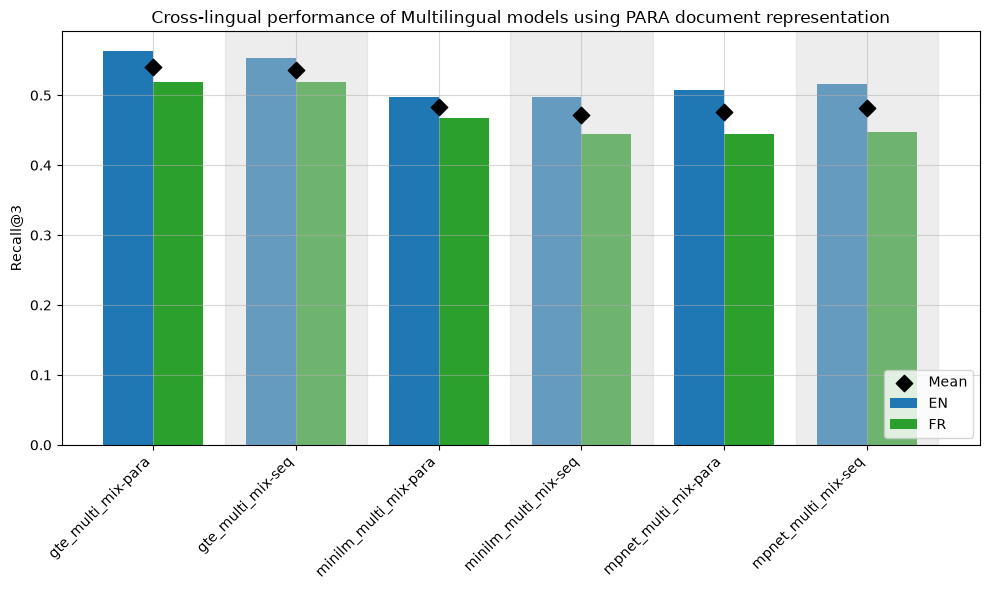

In [37]:
# what about performance on text-para
multilingual_models = ["paraphrase-multilingual-mpnet-base-v2", "paraphrase-multilingual-MiniLM-L12-v2", "gte-multilingual-base"]

subset_df = df[((df["document_repr"]=="text_para")) &
               (df["model"].isin(multilingual_models)) &
               (df["config"].str.contains("mix"))] # only finetuned models!

subset_df['model_short'] = subset_df['model'].map(lambda x: ('mpnet' if 'mpnet' in x.lower() else 'minilm' if 'minilm' in x.lower() else 'gte') + ('_multi' if 'multi' in x.lower() else ''))
subset_df['config_short'] = subset_df['config'].map(lambda x: 'mix-seq' if 'mix-seq' in x.lower() else 'mix-para' if 'mix-para' in x.lower() else "")
subset_df['exp_name'] = subset_df['model_short']+"_"+subset_df['config_short']

df_pivot = subset_df.pivot(index='exp_name', columns='lang', values='cosine_recall@3')
df_pivot = df_pivot[['en', 'fr']]

df_pivot['mean'] = df_pivot.mean(axis=1)

x = np.arange(len(df_pivot))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

# Plot normal bars (keep EN/FR colors)
ax.bar(x - width/2, df_pivot['en'], width, label='EN', color='tab:blue')
ax.bar(x + width/2, df_pivot['fr'], width, label='FR', color='tab:green')

ax.scatter(x, df_pivot['mean'], color='black', s=70, marker='D', label='Mean', zorder=3)

for i, name in enumerate(df_pivot.index):
    if 'seq' in name.lower():
        ax.axvspan(i - 0.5, i + 0.5, color='lightgray', alpha=0.4)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(df_pivot.index, rotation=45, ha='right')

ax.set_title('Cross-lingual performance of Multilingual models using PARA document representation')
ax.set_ylabel('Recall@3')
ax.legend(loc='lower right')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

- Similar to previous graph, performance of models trained using the para repr do sightly better
- performance is ever so slightly higher in the seq case, value-wise.. is it? Checking..

In [38]:
! pip install seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
# mean recall comparison between seq and para variants, evaluated on seq and para respectively
multilingual_models = ["paraphrase-multilingual-mpnet-base-v2", "paraphrase-multilingual-MiniLM-L12-v2", "gte-multilingual-base"]

subset_seq_df = df[(df["document_repr"]=="text_seq") & 
               (df["model"].isin(multilingual_models)) &
               ((df["config"].str.contains("mix-seq")))]

subset_para_df = df[(df["document_repr"]=="text_para") & 
               (df["model"].isin(multilingual_models)) &
               ((df["config"].str.contains("mix-para")))]

subset_df = pd.concat([subset_seq_df, subset_para_df])

subset_df['model_short'] = subset_df['model'].map(lambda x: ('mpnet' if 'mpnet' in x.lower() else 'minilm' if 'minilm' in x.lower() else 'gte') + ('_multi' if 'multi' in x.lower() else ''))
subset_df['config_short'] = subset_df['config'].map(lambda x: 'seq' if 'seq' in x.lower() else 'para')
subset_df['exp_name'] = subset_df['model_short']+"_"+subset_df['config_short']
# subset_df

df_mean = (
    subset_df
    .groupby(['exp_name', 'model_short', 'config_short'], as_index=False)
    .mean(numeric_only=True)
)
df_mean


,exp_name,model_short,config_short,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,cosine_precision@10,cosine_recall@1,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100
0,gte_multi_para,gte_multi,para,0.387755,0.540816,0.609184,0.666327,0.387755,0.180272,0.121837,0.066633,0.387755,0.540816,0.609184,0.666327,0.525107,0.480034,0.487083
1,gte_multi_seq,gte_multi,seq,0.388776,0.543878,0.604082,0.678571,0.388776,0.181293,0.120816,0.067857,0.388776,0.543878,0.604082,0.678571,0.528520,0.481142,0.487188
2,minilm_multi_para,minilm_multi,para,0.333673,0.482653,0.542857,0.630612,0.333673,0.160884,0.108571,0.063061,0.333673,0.482653,0.542857,0.630612,0.474309,0.425285,0.432602
3,minilm_multi_seq,minilm_multi,seq,0.318367,0.469388,0.525510,0.601020,0.318367,0.156463,0.105102,0.060102,0.318367,0.469388,0.525510,0.601020,0.454603,0.408409,0.416815
4,mpnet_multi_para,mpnet_multi,para,0.298980,0.476531,0.534694,0.596939,0.298980,0.158844,0.106939,0.059694,0.298980,0.476531,0.534694,0.596939,0.448251,0.400611,0.407876
5,mpnet_multi_seq,mpnet_multi,seq,0.324490,0.502041,0.545918,0.623469,0.324490,0.167347,0.109184,0.062347,0.324490,0.502041,0.545918,0.623469,0.471531,0.423284,0.430538


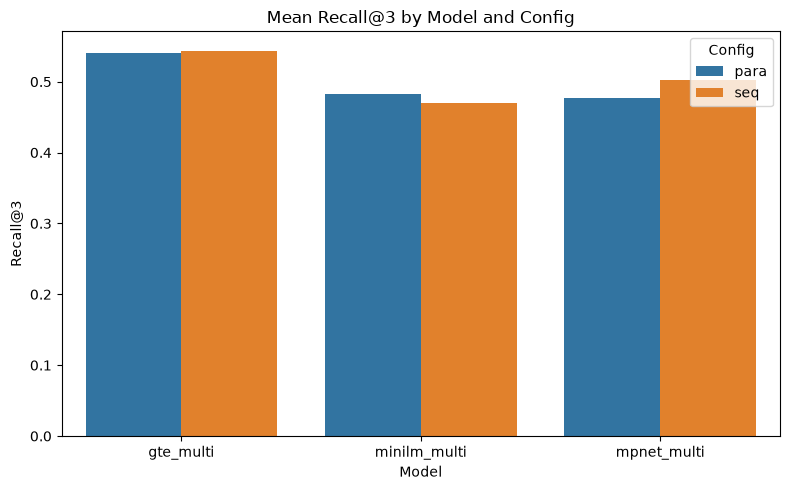

In [40]:
import seaborn as sns
plt.figure(figsize=(8, 5))


sns.barplot(
    data=df_mean,
    x='model_short',
    y='cosine_recall@3',
    hue='config_short'
)

plt.title('Mean Recall@3 by Model and Config')
plt.ylabel('Recall@3')
plt.xlabel('Model')
plt.legend(title='Config')
plt.tight_layout()

plt.show()

For models trained and evaluated for their respective document representation (as the one finetuned on), performance on seq is slightly higher (mpnet and gte case)

## Mono- and Multilingual comparison

In [41]:
# recall of best models

# best monolingual model on en compared to best multilingual model on en-fr
best_mono_on_en = ("all-mpnet-base-v2", "finetune-mnrl-sq512ms2048")
# best_on_en = ("gte-multilingual-base", "finetune-mnrl-mix-para-sq512")

best_multi_on_mix = ("gte-multilingual-base", "finetune-mnrl-mix-seq-sq512")
# best_multi_on_mix = ("gte-multilingual-base", "finetune-mnrl-mix-para-sq1024b16ms1024") # NOT FOR FT AND EVAL ON SAME


subset_df = pd.concat([
    df[(df['model'] == best_mono_on_en[0]) & (df['config'] == best_mono_on_en[1]) & (df['lang'] == 'en') & (df['document_repr'] == 'text_seq')],
    df[(df['model'] == best_multi_on_mix[0]) & (df['config'] == best_multi_on_mix[1]) & (df['lang'] == 'en') & (df['document_repr'] == 'text_seq')]
    ])

subset_df

,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,cosine_precision@10,cosine_recall@1,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100,lang,document_repr,config,model,full_name
8,0.391837,0.563265,0.628571,0.677551,0.391837,0.187755,0.125714,0.067755,0.391837,0.563265,0.628571,0.677551,0.534767,0.488822,0.495053,en,text_seq,finetune-mnrl-sq512ms2048,all-mpnet-base-v2,all-mpnet-base-v2-text_seq-finetune-mnrl-sq512...
98,0.406122,0.561224,0.632653,0.706122,0.406122,0.187075,0.126531,0.070612,0.406122,0.561224,0.632653,0.706122,0.549811,0.500556,0.506335,en,text_seq,finetune-mnrl-mix-seq-sq512,gte-multilingual-base,gte-multilingual-base-text_seq-finetune-mnrl-m...


In [42]:
best_multi_on_mix_seq = ("gte-multilingual-base", "finetune-mnrl-mix-seq-sq512")
best_multi_on_mix_para = ("gte-multilingual-base", "finetune-mnrl-mix-para-sq1024b16ms1024")

subset_df = pd.concat([
    df[(df['model'] == best_multi_on_mix_seq[0]) & (df['config'] == best_multi_on_mix_seq[1]) & (df['lang'] == 'en') & (df['document_repr'] == 'text_para')],
    df[(df['model'] == best_multi_on_mix_para[0]) & (df['config'] == best_multi_on_mix_para[1]) & (df['lang'] == 'en') & (df['document_repr'] == 'text_para')]
    ])

subset_df

,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,cosine_precision@10,cosine_recall@1,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100,lang,document_repr,config,model,full_name
100,0.397959,0.553061,0.628571,0.697959,0.397959,0.184354,0.125714,0.069796,0.397959,0.553061,0.628571,0.697959,0.542199,0.492993,0.499079,en,text_para,finetune-mnrl-mix-seq-sq512,gte-multilingual-base,gte-multilingual-base-text_para-finetune-mnrl-...
106,0.410204,0.563265,0.626531,0.687755,0.410204,0.187755,0.125306,0.068776,0.410204,0.563265,0.626531,0.687755,0.545905,0.500750,0.507956,en,text_para,finetune-mnrl-mix-para-sq1024b16ms1024,gte-multilingual-base,gte-multilingual-base-text_para-finetune-mnrl-...


In [43]:
subset_df = pd.concat([
    df[(df['model'] == best_multi_on_mix_seq[0]) & (df['config'] == best_multi_on_mix_seq[1]) & (df['lang'] == 'fr') & (df['document_repr'] == 'text_para')],
    df[(df['model'] == best_multi_on_mix_para[0]) & (df['config'] == best_multi_on_mix_para[1]) & (df['lang'] == 'fr') & (df['document_repr'] == 'text_para')]
    ])

subset_df

,cosine_accuracy@1,cosine_accuracy@3,cosine_accuracy@5,cosine_accuracy@10,cosine_precision@1,cosine_precision@3,cosine_precision@5,cosine_precision@10,cosine_recall@1,cosine_recall@3,cosine_recall@5,cosine_recall@10,cosine_ndcg@10,cosine_mrr@10,cosine_map@100,lang,document_repr,config,model,full_name
101,0.377551,0.518367,0.565306,0.646939,0.377551,0.172789,0.113061,0.064694,0.377551,0.518367,0.565306,0.646939,0.506583,0.462447,0.469443,fr,text_para,finetune-mnrl-mix-seq-sq512,gte-multilingual-base,gte-multilingual-base-text_para-finetune-mnrl-...
107,0.365306,0.518367,0.591837,0.644898,0.365306,0.172789,0.118367,0.064490,0.365306,0.518367,0.591837,0.644898,0.504309,0.459318,0.466210,fr,text_para,finetune-mnrl-mix-para-sq1024b16ms1024,gte-multilingual-base,gte-multilingual-base-text_para-finetune-mnrl-...


Which config to select: the one FT on seq or on para..

Application-wise, since we are limiting the sequence length for the model, it is best if the doc representation includes en and fr in whatever the model sees - as we can see performance suffers of FR if the onle text visible is EN
So in this case, the model performing best on text-para would be best..

But if we look at the results, the model FT on text-seq actually outperforms the one FTed on text-para.. This is not great for the longevity of these models, typically we want model trained on certain data to be evaluated on the same type of data.
So we sacrifice model seeing both EN and FR, for the slightly better performance when picking seq, but also allow the model to view new information rather than old information in a different language (determined by sequence length)

# Explore actual documents retrieved...

```
scp -J <username>@<server> <username>@<server>:/space/partner/nrcan/geobase/work/oatt/dev/semanticsearch/results/finetune_via_trainer/gte-multilingual-base-baseline/finetune-mnrl-mix-seq-sq512/performance_evaluation/Information-Retrieval_evaluation_query_en_text_seq_predictions_cosine.jsonl ./gte-multi/perf/eval_qen_dseq_finetune-mnrl-mix-seq-sq512summary_on_test.jsonl
```

In [286]:
import pandas as pd
from pathlib import Path

In [287]:
path = Path("./gte-multi/perf/eval_qen_dseq_finetune-mnrl-mix-seq-sq512summary_on_test.jsonl")
path.exists()

True

In [288]:
df = pd.read_json(path, lines=True)
df['top_doc_1'] = df['results'].map(lambda x: x[0]['corpus_id'])
df['top_doc_2'] = df['results'].map(lambda x: x[1]['corpus_id'])
df['top_doc_3'] = df['results'].map(lambda x: x[2]['corpus_id'])

df.head(10)


,query_id,query,results,top_doc_1,top_doc_2,top_doc_3
0,0,native prairie vegetation inventory in alberta,"[{'corpus_id': 0, 'score': 0.768115580081939},...",0,5626,4021
1,1,mnt in 3d,"[{'corpus_id': 1, 'score': 0.648151397705078},...",1,8065,293
2,2,where does soil erosion occur in alberta,"[{'corpus_id': 2, 'score': 0.764256596565246},...",2,8630,6209
3,3,yukon geophysical data,"[{'corpus_id': 4778, 'score': 0.76666516065597...",4778,2911,7165
4,4,stac data,"[{'corpus_id': 3360, 'score': 0.66076087951660...",3360,4466,8036
5,5,lease agreement,"[{'corpus_id': 5753, 'score': 0.52290678024291...",5753,5,9072
6,6,saskatchewan's zones,"[{'corpus_id': 5587, 'score': 0.70106667280197...",5587,8752,6
7,7,what basin is sweetgrass arc in,"[{'corpus_id': 7, 'score': 0.587844908237457},...",7,8083,7443
8,8,spatial location for triassic region of canada,"[{'corpus_id': 9395, 'score': 0.64702641963958...",9395,3966,1018
9,9,physical roughness of a river ice,"[{'corpus_id': 6804, 'score': 0.74417477846145...",6804,9374,1643


In [ ]:
0 - 489     490- 9296(8807+490-1)       9297 - 9785(489 + 9297 - 1)

Query: native prairie vegetation inventory in alberta

Doc #1 Retrieved:
'Native Prairie Vegetation Inventory (NPVI) Polygons\nkeywords:-CANADA, ALBERTA, BIOTA, COVER-TYPE, GRAZING-STATUS, NATIVE-PRAIRIE-VEGETATION-CLASS, NATIVE-VEGETATION, NATURAL-SUBREGION, Government information\nThe Native Prairie Vegetation Inventory (NPVI) Polygons is a quarter section-based vegetation inventory that covers the southern part of Alberta. The native prairie is defined in the Native Prairie Conservation Action Plan as an area of unbroken grassland or parkland dominated by non-introduced species, and an area of previously broken grassland that has reverted back to natural vegetation (30 to 60 years). The Native Prairie Vegetation Inventory extends beyond the Grasslands Natural Region to include data for adjacent areas, such as the Cypress Hills. In addition to the Grassland Natural Region, the Native Prairie Vegetation Inventory (NPVI) Polygons include areas that belong to the Foothills Parkland, Central Parkland, Montane, Dry Mixedwood Boreal and Lower Foothills Natural Subregions.'

Doc #2 Retrieved:
"Grassland Vegetation Inventory (GVI)\nkeywords:BIOTA, GEOSCIENTIFICINFORMATION, GRASSLAND, INLANDWATERS, PLANNINGCADASTRE, RANGE, SOCIETY, VEGETATION, WETLAND, Government information\nThis dataset is produced for the Government of Alberta and is available to the general public. Please consult the Distribution Information of this metadata on how to acquire this dataset. The Grassland Vegetation Inventory (GVI) represents the Government of Alberta's comprehensive biophysical, anthropogenic and land-use inventory of the southernmost portion of the province's White Area. The compilation of the inventory commenced in 2006 in the southeast corner of the province using digital colour-infrared stereo photography. Data capture has proceeded north and west. The Grassland Vegetation Inventory is intended as an update to the Native Prairie Vegetation Inventory (NPVI) that was completed circa 1993. The Grassland Vegetation Inventory product is a more comprehensive and detailed geospatial representation of land cover that is intended to meet a multitude of business needs integral to land-use planning and management in Alberta. The Grassland Vegetation Inventory is a biophysical and land-use inventory rather than a purely vegetation inventory. It is comprised of ecological range sites based on soils information for areas of native vegetation and general land use for areas of non-native vegetation, namely those associated with agricultural, industrial, and residential developments. Landscape Polygons are the basic map units in the Grassland Vegetation Inventory digital product. These polygons represent interpretations of relatively uniform biophysical or anthropogenic areas. The characteristics of Landscape Polygons are captured as records in the Sites table. The Grassland Vegetation Inventory site type classification is captured under the Site Types column in the Sites table to a maximum of four site types per Landscape Polygon. The Grassland Vegetation Inventory site types and their associated information plus the data capture methodology are described in the Grassland Vegetation Inventory Specifications. Grassland Vegetation Inventory projects were initially funded under the Base Data Acquisition component of the Land-use Framework program, which represents the Alberta Government's comprehensive and integrated approach to land use planning and management. The primary funding agency is Alberta Environment and Protected Areas. The GVI data, index map, status map, views and specifications documents are available from Alberta Environment and Protected Areas, Government of Alberta."

Doc #3 Retreived:
Prairie Grassland Land Cover\nkeywords:Grasslands, Agriculture, Land cover, Forage crops\nThe Grassland Inventory provides a standardized, high-resolution land cover classification for the grassland ecosystems in Canada. Developed using a random forest classification on multi-temporal Sentinel-1 SAR and Sentinel-2 Optical imagery, the series differentiates intact native grasslands from high-disturbance, tame perennial forage systems; two classes that are spectrally and phenologically similar, yet critical to differentiate and quantify accurately for carbon and biodiversity modelling. Each release in the series includes a categorical 10 m land cover raster and a companion continuous likelihood layer representing model confidence in the native grassland class. As new classifications are added (semi-decadal) and geographic extent increased, the series will enable consistent temporal comparisons to track grassland dynamics and land cover change to support operational and research applications within AAFC and stakeholders.


Query: mnt in 3d

Doc #1 Retrieved:
'3D buildings 2016 (LOD2 model with textures)\nkeywords:3D, Building, Mockup, SIRR, Government information\nDigital model of 3D LOD2 buildings with textures in CityGML, 3DM and GDB format and in DWG format without textures of some Montreal boroughs.\n[The digital terrain model (MNT)] (donnees.montreal.ca [url]) of some districts is also available to present the complete digital model of the territory.*This third party metadata element was translated using an automated translation tool (Amazon Translate).*'

Doc #2 Retrieved:
'3D building 2013 (CityGML LOD2 model with textures) (archives)\nkeywords:3D, Building, Mockup, SIRR, Elevation, Government information\nDigital model of 3D LOD2 buildings with textures in CityGML and 3DM format of some boroughs of Montreal.\nThe [digital terrain model (MNT)] (donnees.montreal.ca [url]) of these districts is also available to present the complete digital model of the territory.\n*This third party metadata element was translated using an automated translation tool (Amazon Translate).*'

Doc #3 Retrieved:
'Digital Terrain Model (DTM)\nkeywords:DTM, MNT, terrain, model, elevation, spot height, modèle, Altimetric rating, Geonb, new brunswick, Government information\nA digital terrain model (DTM) is a digital representation of elevations throughout the Province. DTM files contain elevation mass points, check points, spot heights and random densified points. The spacing between the elevation points is approximately 70 metres and the absolute vertical accuracy of a single elevation point is approximately 2.5 metres. The elevations are expressed as metres above mean sea level.'

Query: where does soil erosion occur in alberta

Doc #1 Retrieved:
'Soil Erosion Risk\nkeywords:ALBERTA, DOWNLOADABLE-DATA, FARMING, GEOSCIENTIFICINFORMATION, SEDIMENTATION, SOIL-DEGRADATION, SOIL-LOSS, Government information\nThis map displays an assessment of soil erosion risk for the agricultural area of Alberta. Loss of protective residue cover through cultivation will increase the potential risk of soil erosion. The vulnerability of the soil to erosion combined with the intensity of cultivation determines the degree to which the soil may be at risk. The classes shown on the map were ranked from 0 (lowest risk) to 1 (highest risk). This resource was created in 2002 using ArcGIS.'

Doc #2 Retrieved:
'Water Erosion Risk\nkeywords:ALBERTA, DOWNLOADABLE-DATA, GEOSCIENTIFICINFORMATION, INLANDWATERS, LOSSES-FROM-SOIL, RAIN-EROSION, RUNOFF-WATER, SEDIMENTATION, Government information\nThis map displays the risk of soil degradation by water in the agricultural region of Alberta. Water erosion is a concern because it reduces soil quality by removing soil particles and nutrients, and reduces water quality if these particles are carried into nearby water bodies. The map uses five classes to describe the water erosion risk on bare, unprotected mineral soil: negligible, low, moderate, high and severe.This resource was created using ArcGIS, originally published as a print map in 1993 .'

Doc #3 Retrieved:
'Wind Erosion Risk\nkeywords:ALBERTA, CLIMATOLOGYMETEOROLOGYATMOSPHERE, DESERTIFICATION, DOWNLOADABLE-DATA, GEOSCIENTIFICINFORMATION, SOIL-FERTILITY, SOIL-MOVEMENT, Government information\nThis map displays the risk of soil degradation by wind in the agricultural region of Alberta. Wind erosion is a concern because it reduces soil quality by removing soil nutrients, smaller soil particles and organic matter. Wind erosion can reduce air quality during extreme erosion events and also reduce water quality if eroded particles drift into streams and lakes. The map uses five classes to describe the wind erosion risk on bare, unprotected mineral soil: negligible, low, moderate, high and severe. This resource was created using ArcGIS. It was originally published as a print map in 1989.'

Query: yukon geophysical data

Doc #1 Retrieved:
'Reprocessing of Yukon magnetic data for NTS 115K\nkeywords:geophysics, magnetic-survey, ygs-import, ygs-import-20250711, ygs-publications, yukon-geological-survey, Government information\nAurora Geosciences Ltd was contracted to perform a review of publicly available digital magnetic geophysical data submitted with assessment reports to develop standardized products and compilations. Data submitted prior to March 2015 were considered.\nIndividual assessment report data were levelled and integrated with 1:250 000 compilations.\nFour gridded PDFs have been produced (residual total magnetic field, reduced to pole, vertical derivative and tilt derivative). Original 250k geophysical data can be found in YGS Open File 2017-40.'

Doc #2 Retrieved:
'Reprocessing of Yukon magnetic data for NTS 115F\nkeywords:geophysics, magnetic-survey, ygs-import, ygs-import-20250711, ygs-publications, yukon-geological-survey, Government information\nAurora Geosciences Ltd was contracted to perform a review of publicly available digital magnetic geophysical data submitted with assessment reports to develop standardized products and compilations. Data submitted prior to March 2015 were considered.\nIndividual assessment report data were levelled and integrated with 1:250 000 compilations.\nFour gridded PDFs have been produced (residual total magnetic field, reduced to pole, vertical derivative and tilt derivative). Original 250k geophysical data can be found in YGS Open File 2017-35.'

Doc #3 Retrieved:
'Reprocessing of Yukon magnetic data for NTS 115J\nkeywords:geophysics, magnetic-survey, ygs-import, ygs-import-20250711, ygs-publications, yukon-geological-survey, Government information\nAurora Geosciences Ltd was contracted to perform a review of publicly available digital magnetic geophysical data submitted with assessment reports to develop standardized products and compilations. Data submitted prior to March 2015 were considered.\nIndividual assessment report data were levelled and integrated with 1:250 000 compilations.\nFour gridded PDFs have been produced (residual total magnetic field, reduced to pole, vertical derivative and tilt derivative). Original 250k geophysical data can be found in YGS Open File 2017-39.'

Query: saskatchewan's zones

Doc #1 Retrieved:
"Saskatchewan COVID-19 Boundaries\nkeywords:Saskatchewan, Health, GoS, COVID-19, Government information\nBoundaries developed for use when aggregating cases and reporting during the COVID-19 pandemic in Saskatchewan.\nThe province of Saskatchewan has been divided into six distinct areas for use in reporting the infection rates of COVID-19 during the 2020 outbreak of the virus.This dataset is\xa0'Deprecated'. Please use updated source\xa0here."

Doc #2 Retrieved:
'Saskatchewan COVID-19 Zones\nkeywords:analysis result, join features, covid-19, government of saskatchewan, health, Government information\nBoundaries for reporting cases of COVID-19 in Saskatchewan. Areas, zones and subzones show the different geographies available; these boundaries are based on statistics Canada source geometry when possible.\nOn August 4th 2020, the province announced it would change the method of reporting COVID-19 cases, moving from six regions based on former Regional Health Authorities to thirteen zones based on Saskatchewan Health Authority geographies. The COVID-19 Zones are made by aggregating the COVID-19 Subzones, which are based on the SHA Health Networks or aggregations thereof. The COVID-19 Areas are an aggregation of the COVID-19 Zones.\xa0\xa0Areas, zones and subzones show the different geographies available; these boundaries are based on statistics Canada source geometry when possible.'

Doc #3 Retrieved:
'Saskatchewan COVID-19 Zones\nkeywords:analysis result, join features, covid-19, government of saskatchewan, health, Government information\nSaskatchewan COVID-19 Zones'

Query: spatial location for triassic region of canada

Doc #1 Retrieved:
'Index Map of Triassic Rocks (GIS data, polygon features)\nkeywords:72E, 72L, 72M, 73D, 73E, 73L, 73M, 74D, 74E, 74L, 74M, 82G, 82H, 82I, 82J, 82N, 82O, 82P, 83A, 83B, 83C, 83D, 83E, 83F, 83G, 83H, 83I, 83J, 83K, 83L, 83M, 83N, 83O, 83P, 84A, 84B, 84C, 84D, 84E, 84F, 84G, 84H, 84I, 84J, 84K, 84L, 84M, 84N, 84O, 84P, ALBERTA, CANADA, GEOLOGY, GEOSCIENTIFICINFORMATION, GIS-DATA, WESTERN-CANADA, WESTERN-CANADA-SEDIMENTARY-BASIN, Government information\nThe Geological Atlas of the Western Canada Sedimentary Basin was designed primarily as a reference volume documenting the subsurface geology of the Western Canada Sedimentary Basin. This GIS dataset is one of a collection of shapefiles representing part of Chapter 16 of the Atlas, Triassic Strata of the Western Canada Sedimentary Basin, Figure 1, Index Map of Triassic Rocks. Shapefiles were produced from archived digital files created by the Alberta Geological Survey in the mid-1990s, and edited in 2005-06 to correct, attribute and consolidate the data into single files by feature type and by figure.'

Doc #2 Retrieved:
'Index Map of Triassic Rocks (GIS data, line features)\nkeywords:82G, 82J, 82N, 82O, 83B, 83C, 83D, 83E, 83F, 83G, 83J, 83K, 83L, 83M, 83N, 83O, 84B, 84C, 84D, 84E, 84F, 84G, 84J, 84K, 84L, 84M, 84N, 84O, ALBERTA, CANADA, GEOLOGY, GEOSCIENTIFICINFORMATION, GIS-DATA, WESTERN-CANADA, WESTERN-CANADA-SEDIMENTARY-BASIN, Government information\nThe Geological Atlas of the Western Canada Sedimentary Basin was designed primarily as a reference volume documenting the subsurface geology of the Western Canada Sedimentary Basin. This GIS dataset is one of a collection of shapefiles representing part of Chapter 16 of the Atlas, Triassic Strata of the Western Canada Sedimentary Basin, Figure 1, Index Map of Triassic Rocks. Shapefiles were produced from archived digital files created by the Alberta Geological Survey in the mid-1990s, and edited in 2005-06 to correct, attribute and consolidate the data into single files by feature type and by figure.'

Doc #3 Retrieved: 
'Triassic (PT2) Paleogeography (GIS data, polygon features)\nkeywords:72L, 72M, 73D, 73E, 73L, 73M, 74D, 74E, 74L, 74M, 82G, 82I, 82J, 82N, 82O, 82P, 83A, 83B, 83C, 83D, 83E, 83F, 83G, 83H, 83I, 83J, 83K, 83L, 83M, 83N, 83O, 83P, 84A, 84B, 84C, 84D, 84E, 84F, 84G, 84H, 84I, 84J, 84K, 84L, 84M, 84N, 84O, 84P, ALBERTA, CANADA, GEOLOGY, GEOSCIENTIFICINFORMATION, GIS-DATA, WESTERN-CANADA, WESTERN-CANADA-SEDIMENTARY-BASIN, Government information\nThe Geological Atlas of the Western Canada Sedimentary Basin was designed primarily as a reference volume documenting the subsurface geology of the Western Canada Sedimentary Basin. This GIS dataset is one of a collection of shapefiles representing part of Chapter 7 of the Atlas, Paleographic Evolution of the Cratonic Platform - Cambrian to Triassic, Figure 14, Triassic (PT2) Paleogeography. Shapefiles were produced from archived digital files created by the Alberta Geological Survey in the mid-1990s, and edited in 2005-06 to correct, attribute and consolidate the data into single files by feature type and by figure.'

Query: physical roughness of a river ice

Doc #1 Retrieved:
'River Ice in Canada - Current Year\nkeywords:Natural disasters, Emergency services, Ice\nRiver ice roughness products from the current calendar year in selected Canadian regions that have been designated for observation, monitored by Natural Resources Canada using satellite imagery for emergency response. Coverage is not comprehensive nationwide. \nIn order to mitigate ice jam induced floods risks, Natural Resources Canada emergency geomatics service (EGS) may be activated by Canada’s emergency management authorities. As new satellite imagery becomes available, NRCan will produce river ice roughness maps and update the dataset in near real time (4 hours). This item contains record of the river ice roughness products generated in the current year. For the complete archive, please refer to the [River Ice in Canada - Archive](open.canada.ca [url]) entry.\nThe river ice product is generated and validated on a best effort basis. Various factors may affect the quality of the river ice roughness maps. Those factors include but are not limited to: environmental condition at the time of acquisition, image resolution or the limitations of the methodology used. \nTo view a specific product, filter the data by date (UTC Date) and area of interest (AOI). Links to download specific EGS product are available in the Resources section.\nDisclaimer:\nEmergency response authorities are the primary users of these satellite-derived river ice roughness map products. These products are generated to provide analysis and emergency response situational awareness and to facilitate decision-making during major flood events. The river ice roughness products are generated rapidly and limited time is available for editing and validation. The river ice roughness products reflect the river ice surface roughness conditions at the date/time of acquisition. While efforts are made to produce high quality products, near-real time products may contain errors due to the limited time available for validation and the limited availability of ground truthing data.\nLimitation of Liability:\nAccordingly, the information contained on this website is provided on an “as is” basis and Natural Resources Canada makes no representations or warranties respecting the information, either expressed or implied, arising by law or otherwise, including but not limited to, effectiveness, completeness, accuracy or fitness for a particular purpose. Natural Resources Canada does not assume any liability in respect of any damage or loss based on the use of this website. In no event shall Natural Resources Canada be liable in any way for any direct, indirect, special, incidental, consequential, or other damages based on any use of this website or any other website to which this site is linked, including, without limitation, any lost profits or revenue or business interruption.\nParent Collection:\n- *[River Ice State in Canada - Cartographic Product Collection](open.canada.ca [url])*'

Doc #2 Retrieved:
'Active Monitoring of River Ice in Canada\nkeywords:Ice, Emergency services, Natural disasters\nRiver ice roughness as it is actively monitored on selected rivers by Natural Resources Canada (NRCan) using satellite imagery for the mitigation of ice jam associated risks. \nIn order to mitigate ice jam induced flood risks, Natural Resources Canada emergency geomatics service (EGS) may be activated by Canada’s emergency management authorities. As new satellite imagery becomes available, NRCan will produce river ice roughness maps and update the dataset in near real time (4 hours). This item contains the latest river ice roughness products generated in the past three days. For any data older than 72 hours, please refer to the [River Ice in Canada - Seasonal](open.canada.ca [url]) entry. \nThe river ice product is generated and validated on a best effort basis. Various factors may affect the quality of the river ice roughness maps. Those factors include but are not limited to: environmental condition at the time of acquisition, image resolution or the limitations of the methodology used. \nTo view a specific product in Web Services, filter the data by date (UTC Date) and area of interest (AOI). A link to download specific EGS products is available in the Resources section.\nDisclaimer:\nEmergency response authorities are the primary users of these satellite-derived river ice roughness map products. These products are generated to provide analysis and emergency response situational awareness and to facilitate decision-making during major flood events. The river ice roughness products are generated rapidly and limited time is available for editing and validation. The river ice roughness products reflect the river ice surface roughness conditions at the date/time of acquisition. While efforts are made to produce high quality products, near-real time products may contain errors due to the limited time available for validation and the limited availability of ground truthing data. \nLimitation of Liability:\nAccordingly, the information contained on this website is provided on an “as is” basis and Natural Resources Canada makes no representations or warranties respecting the information, either expressed or implied, arising by law or otherwise, including but not limited to, effectiveness, completeness, accuracy or fitness for a particular purpose. Natural Resources Canada does not assume any liability in respect of any damage or loss based on the use of this website. In no event shall Natural Resources Canada be liable in any way for any direct, indirect, special, incidental, consequential, or other damages based on any use of this website or any other website to which this site is linked, including, without limitation, any lost profits or revenue or business interruption.\nParent Collection:\n- *[River Ice State in Canada - Cartographic Product Collection](open.canada.ca [url])*'

Doc #3 Retrieved:
'River Ice in Canada - Archive\nkeywords:Ice, History, Natural disasters, Archives, Emergency services\nArchive of river ice roughness as monitored on selected rivers by Natural Resources Canada (NRCan) using satellite imagery for the mitigation of ice jam associated risks. \nIn order to mitigate ice jam induced floods risks, Natural Resources Canada emergency geomatics service (EGS) may be activated by Canada’s emergency management authorities. As new satellite imagery becomes available, NRCan will produce river ice roughness maps and update the dataset in near real time (4 hours). This item contains the complete record of the river ice roughness products generated in past years. For any data to the current year, please refer to the [River Ice in Canada - Seasonal](open.canada.ca [url]) entry.\nThe river ice product is generated and validated on a best effort basis. Various factors may affect the quality of the river ice roughness maps. Those factors include but are not limited to: sensor type, image resolution or the limitations of the methodology used. \nTo view a specific product in Web Services, filter the data by date (UTC Date) and area of interest (AOI). A link to download specific EGS products is available in the Resources section. \nDisclaimer:\nEmergency response authorities are the primary users of these satellite-derived river ice roughness map products. These products are generated to provide analysis and emergency response situational awareness and to facilitate decision-making during major flood events. The river ice roughness products are generated rapidly and limited time is available for editing and validation. The river ice roughness products reflect the river ice surface roughness conditions at the date/time of acquisition. While efforts are made to produce high quality products, near-real time products may contain errors due to the limited time available for validation and the limited availability of ground truthing data.\nLimitation of Liability:\nAccordingly, the information contained on this website is provided on an “as is” basis and Natural Resources Canada makes no representations or warranties respecting the information, either expressed or implied, arising by law or otherwise, including but not limited to, effectiveness, completeness, accuracy or fitness for a particular purpose. Natural Resources Canada does not assume any liability in respect of any damage or loss based on the use of this website. In no event shall Natural Resources Canada be liable in any way for any direct, indirect, special, incidental, consequential, or other damages based on any use of this website or any other website to which this site is linked, including, without limitation, any lost profits or revenue or business interruption.\nParent Collection:\n- *[River Ice State in Canada - Cartographic Product Collection](open.canada.ca [url])*'

In [252]:
df.iloc[3]['results']

[{'corpus_id': 4779, 'score': 0.766665160655975},
 {'corpus_id': 2912, 'score': 0.7656338214874261},
 {'corpus_id': 7166, 'score': 0.7647626996040341},
 {'corpus_id': 5661, 'score': 0.764523267745971},
 {'corpus_id': 8764, 'score': 0.760693669319152},
 {'corpus_id': 4899, 'score': 0.7597159743309021},
 {'corpus_id': 3552, 'score': 0.759101450443267},
 {'corpus_id': 5978, 'score': 0.758108496665954},
 {'corpus_id': 7552, 'score': 0.7574586868286131},
 {'corpus_id': 6844, 'score': 0.7572473287582391},
 {'corpus_id': 3, 'score': 0.754718244075775},
 {'corpus_id': 7024, 'score': 0.7538037896156311},
 {'corpus_id': 8247, 'score': 0.7527944445610041},
 {'corpus_id': 2883, 'score': 0.7515430450439451},
 {'corpus_id': 75, 'score': 0.7512051463127131},
 {'corpus_id': 6525, 'score': 0.7510238289833061},
 {'corpus_id': 2599, 'score': 0.748908817768096},
 {'corpus_id': 8944, 'score': 0.748587429523468},
 {'corpus_id': 8109, 'score': 0.7484052181243891},
 {'corpus_id': 8052, 'score': 0.748348772525

>>> import pandas as pd
>>> from pathlib import Path
>>> path = Path("./results/finetune_via_trainer/gte-multilingual-base-baseline/finetune-mnrl-mix-seq-sq512/performance_evaluation/Information-Retrieval_evaluation_query_en_text_seq_predictions_cosine.jsonl")
>>> path.exists()
True
>>> df = pd.read_json(path, lines=True)
>>> df['top_doc_1'] = df['results'].map(lambda x: x[0]['corpus_id'])
>>> df['top_doc_2'] = df['results'].map(lambda x: x[1]['corpus_id'])
>>> df['top_doc_3'] = df['results'].map(lambda x: x[2]['corpus_id'])
>>> train_docs_df = pd.read_parquet("./data/preprocessed-se/with_synthetic_queries/train.parquet")
>>> test_docs_df = pd.read_parquet("./data/preprocessed-se/with_synthetic_queries/test.parquet")
>>> eval_docs_df = pd.read_parquet("./data/preprocessed-se/with_synthetic_queries/eval.parquet")

>>> df.iloc[0][['query', 'top_doc_1', 'top_doc_2', 'top_doc_3']]
query        native prairie vegetation inventory in alberta
top_doc_1                                                 0
top_doc_2                                              5627
top_doc_3                                              4022
Name: 0, dtype: object

>>> test_docs_df = pd.read_parquet("./data/preprocessed-se/with_synthetic_queries/test.parquet")
>>> test_docs_df = test_docs_df.sample(frac=1, random_state=42)
>>> test_docs_df.iloc[0]['text_en']
'Native Prairie Vegetation Inventory (NPVI) Polygons\nkeywords:-CANADA, ALBERTA, BIOTA, COVER-TYPE, GRAZING-STATUS, NATIVE-PRAIRIE-VEGETATION-CLASS, NATIVE-VEGETATION, NATURAL-SUBREGION, Government information\nThe Native Prairie Vegetation Inventory (NPVI) Polygons is a quarter section-based vegetation inventory that covers the southern part of Alberta. The native prairie is defined in the Native Prairie Conservation Action Plan as an area of unbroken grassland or parkland dominated by non-introduced species, and an area of previously broken grassland that has reverted back to natural vegetation (30 to 60 years). The Native Prairie Vegetation Inventory extends beyond the Grasslands Natural Region to include data for adjacent areas, such as the Cypress Hills. In addition to the Grassland Natural Region, the Native Prairie Vegetation Inventory (NPVI) Polygons include areas that belong to the Foothills Parkland, Central Parkland, Montane, Dry Mixedwood Boreal and Lower Foothills Natural Subregions.'
>>> train_docs_df = pd.read_parquet("./data/preprocessed-se/with_synthetic_queries/train.parquet").sample(frac=1, random_state=42)
>>> test_docs_df.shape
(490, 16)
>>> train_docs_df.shape
(8807, 16)
>>> 5627-490
5137
>>> train_docs_df.iloc[5136]['text_en']
"Grassland Vegetation Inventory (GVI)\nkeywords:BIOTA, GEOSCIENTIFICINFORMATION, GRASSLAND, INLANDWATERS, PLANNINGCADASTRE, RANGE, SOCIETY, VEGETATION, WETLAND, Government information\nThis dataset is produced for the Government of Alberta and is available to the general public. Please consult the Distribution Information of this metadata on how to acquire this dataset. The Grassland Vegetation Inventory (GVI) represents the Government of Alberta's comprehensive biophysical, anthropogenic and land-use inventory of the southernmost portion of the province's White Area. The compilation of the inventory commenced in 2006 in the southeast corner of the province using digital colour-infrared stereo photography. Data capture has proceeded north and west. The Grassland Vegetation Inventory is intended as an update to the Native Prairie Vegetation Inventory (NPVI) that was completed circa 1993. The Grassland Vegetation Inventory product is a more comprehensive and detailed geospatial representation of land cover that is intended to meet a multitude of business needs integral to land-use planning and management in Alberta. The Grassland Vegetation Inventory is a biophysical and land-use inventory rather than a purely vegetation inventory. It is comprised of ecological range sites based on soils information for areas of native vegetation and general land use for areas of non-native vegetation, namely those associated with agricultural, industrial, and residential developments. Landscape Polygons are the basic map units in the Grassland Vegetation Inventory digital product. These polygons represent interpretations of relatively uniform biophysical or anthropogenic areas. The characteristics of Landscape Polygons are captured as records in the Sites table. The Grassland Vegetation Inventory site type classification is captured under the Site Types column in the Sites table to a maximum of four site types per Landscape Polygon. The Grassland Vegetation Inventory site types and their associated information plus the data capture methodology are described in the Grassland Vegetation Inventory Specifications. Grassland Vegetation Inventory projects were initially funded under the Base Data Acquisition component of the Land-use Framework program, which represents the Alberta Government's comprehensive and integrated approach to land use planning and management. The primary funding agency is Alberta Environment and Protected Areas. The GVI data, index map, status map, views and specifications documents are available from Alberta Environment and Protected Areas, Government of Alberta."

>>> train_docs_df.iloc[8753-test_docs_df.shape[0]-1]['text_en']
>>> eval_docs_df.iloc[9396 - test_docs_df.shape[0] - 1 - train_docs_df.shape[0] - 1]['text_en']

/# creating corpus

>>> from pathlib import Path
>>> path = Path("./results/finetune_via_trainer/gte-multilingual-base-baseline/finetune-mnrl-mix-seq-sq512/performance_evaluation/Information-Retrieval_evaluation_query_en_text_seq_predictions_cosine.jsonl")
>>> path.exists()
True
>>> df = pd.read_json(path, lines=True)
KeyboardInterrupt
>>> train_docs_df = pd.read_parquet("./data/preprocessed-se/with_synthetic_queries/train.parquet").sample(frac=1, random_state=42)
>>> test_docs_df = pd.read_parquet("./data/preprocessed-se/with_synthetic_queries/test.parquet").sample(frac=1, random_state=42)
>>> eval_docs_df = pd.read_parquet("./data/preprocessed-se/with_synthetic_queries/eval.parquet").sample(frac=1, random_state=42)
>>> train_docs_df.columns
Index(['features_properties_id', 'features_properties_title_en',
       'features_properties_title_fr', 'features_properties_description_en',
       'features_properties_description_fr', 'features_properties_keywords_en',
       'features_properties_keywords_fr', 'features_properties_eoCollection',
       'features_properties_description_normalized_en',
       'features_properties_description_normalized_fr', 'text_en', 'text_fr',
       'text_seq', 'text_para', 'query_en', 'query_fr'],
      dtype='object')
>>> full_corpus = pd.concat([test_docs_df, train_docs_df, eval_docs_df], ignore_index=True)
>>> full_corpus = full_corpus.drop(columns=['query_en', 'query_fr'])
>>> full_corpus.columns
Index(['features_properties_id', 'features_properties_title_en',
       'features_properties_title_fr', 'features_properties_description_en',
       'features_properties_description_fr', 'features_properties_keywords_en',
       'features_properties_keywords_fr', 'features_properties_eoCollection',
       'features_properties_description_normalized_en',
       'features_properties_description_normalized_fr', 'text_en', 'text_fr',
       'text_seq', 'text_para'],
      dtype='object')
>>> full_corpus.to_parquet('./data/preprocessed-se/with_synthetic_queries/full_corpus.parquet')

>>> import pandas as pd
>>> real_eval = pd.read_excel("./data/benckmark/by_geo_theme/query2title.xlsx", sheet_name=None)
Traceback (most recent call last):
  File "<stdin>", line 1, in <module>
  File "/gpfs/fs5/nrcan/nrcan_geobase/work/oatt/opt/miniconda3/envs/semantic-finetune/lib/python3.9/site-packages/pandas/io/excel/_base.py", line 495, in read_excel
    io = ExcelFile(
  File "/gpfs/fs5/nrcan/nrcan_geobase/work/oatt/opt/miniconda3/envs/semantic-finetune/lib/python3.9/site-packages/pandas/io/excel/_base.py", line 1550, in __init__
    ext = inspect_excel_format(
  File "/gpfs/fs5/nrcan/nrcan_geobase/work/oatt/opt/miniconda3/envs/semantic-finetune/lib/python3.9/site-packages/pandas/io/excel/_base.py", line 1402, in inspect_excel_format
    with get_handle(
  File "/gpfs/fs5/nrcan/nrcan_geobase/work/oatt/opt/miniconda3/envs/semantic-finetune/lib/python3.9/site-packages/pandas/io/common.py", line 882, in get_handle
    handle = open(handle, ioargs.mode)
FileNotFoundError: [Errno 2] No such file or directory: './data/benckmark/by_geo_theme/query2title.xlsx'
>>> real_eval = pd.read_excel("data/benchmark/by_geo_theme/query2title.xlsx", sheet_name=None)
>>> real_eval.head()
Traceback (most recent call last):
  File "<stdin>", line 1, in <module>
AttributeError: 'dict' object has no attribute 'head'
>>> df_list = []
>>> for key, val in real_eval.items():
...     df = real_eval[key]
...     df['geo_theme'] = key
...     df_list.append(df)
...
>>> full_df = pd.concat(df_list, ignore_index=True).reset_index()
>>> full_df.head()
   index                                              query                                  related documents      geo_theme
0      0  Where can I find information on the legislativ...  National Parks and National Park Reserves of C...  Adminstrative
1      1  Where can I find data on Canada's federal elec...  Administrative and Electoral Boundaries of Can...  Adminstrative
2      2   the names and locations of First Nations thro...                                                NaN  Adminstrative
3      3  What dataset includes the digital representati...                                                NaN  Adminstrative
4      4  How can I find information about the Rouge Nat...  National Parks and National Park Reserves of C...  Adminstrative
>>> full_df = pd.concat(df_list, ignore_index=True)
>>> full_df.head()
                                               query                                  related documents      geo_theme
0  Where can I find information on the legislativ...  National Parks and National Park Reserves of C...  Adminstrative
1  Where can I find data on Canada's federal elec...  Administrative and Electoral Boundaries of Can...  Adminstrative
2   the names and locations of First Nations thro...                                                NaN  Adminstrative
3  What dataset includes the digital representati...                                                NaN  Adminstrative
4  How can I find information about the Rouge Nat...  National Parks and National Park Reserves of C...  Adminstrative
>>> full_df = full_df[~full_df['related documents'].isna()]
>>> full_df.head()
                                               query                                  related documents      geo_theme
0  Where can I find information on the legislativ...  National Parks and National Park Reserves of C...  Adminstrative
1  Where can I find data on Canada's federal elec...  Administrative and Electoral Boundaries of Can...  Adminstrative
4  How can I find information about the Rouge Nat...  National Parks and National Park Reserves of C...  Adminstrative
5  2015 Canadian household income by census subdi...  Median total income of households in 2015 (dol...        Economy
6  Indigenous Services Canada infrastructure inve...  Targeted Investments in First Nations Communit...        Economy
>>> corpus_df.head()
Traceback (most recent call last):
  File "<stdin>", line 1, in <module>
NameError: name 'corpus_df' is not defined
>>> corpus_df = pd.read_parquet('data/preprocessed_se/full_corpus.parquet')
Traceback (most recent call last):
  File "<stdin>", line 1, in <module>
  File "/gpfs/fs5/nrcan/nrcan_geobase/work/oatt/opt/miniconda3/envs/semantic-finetune/lib/python3.9/site-packages/pandas/io/parquet.py", line 667, in read_parquet
    return impl.read(
  File "/gpfs/fs5/nrcan/nrcan_geobase/work/oatt/opt/miniconda3/envs/semantic-finetune/lib/python3.9/site-packages/pandas/io/parquet.py", line 267, in read
    path_or_handle, handles, filesystem = _get_path_or_handle(
  File "/gpfs/fs5/nrcan/nrcan_geobase/work/oatt/opt/miniconda3/envs/semantic-finetune/lib/python3.9/site-packages/pandas/io/parquet.py", line 140, in _get_path_or_handle
    handles = get_handle(
  File "/gpfs/fs5/nrcan/nrcan_geobase/work/oatt/opt/miniconda3/envs/semantic-finetune/lib/python3.9/site-packages/pandas/io/common.py", line 882, in get_handle
    handle = open(handle, ioargs.mode)
FileNotFoundError: [Errno 2] No such file or directory: 'data/preprocessed_se/full_corpus.parquet'
>>> corpus_df = pd.read_parquet('data/preprocessed-se/with_synthetic_queries/full_corpus.parquet')
>>> corpus_df.head()
                        features_properties_id  ...                                          text_para
0         1a3357f4-0cbe-405d-9573-1b4dede8a903  ...  Native Prairie Vegetation Inventory (NPVI) Pol...
1         5eabd047-872e-425a-bbc2-3669e732a132  ...  3D buildings 2016 (LOD2 model with textures)\n...
2         c33009d4-ab42-415d-a19e-32bb1d462385  ...  Soil Erosion Risk\nRisque d'érosion du sol\nke...
3         a23d888d-36bc-40be-a246-8e550609dccb  ...  Reprocessing of Yukon magnetic data for NTS 10...
4  ccmeo-hrdem-lidar-QC-Ivujivik_UTM18_2022-1m  ...  STAC-Item - QC Ivujivik UTM18 2022 1m - Mosaic...

[5 rows x 14 columns]
>>> query2doc = pd.merge(full_df, corpus_df, left_on="related_documents", right_on="")
KeyboardInterrupt
>>> corpus_df.columns
Index(['features_properties_id', 'features_properties_title_en',
       'features_properties_title_fr', 'features_properties_description_en',
       'features_properties_description_fr', 'features_properties_keywords_en',
       'features_properties_keywords_fr', 'features_properties_eoCollection',
       'features_properties_description_normalized_en',
       'features_properties_description_normalized_fr', 'text_en', 'text_fr',
       'text_seq', 'text_para'],
      dtype='object')
>>> query2doc = pd.merge(full_df, corpus_df, left_on="related_documents", right_on="features_properties_title_en", how="left")
Traceback (most recent call last):
  File "<stdin>", line 1, in <module>
  File "/gpfs/fs5/nrcan/nrcan_geobase/work/oatt/opt/miniconda3/envs/semantic-finetune/lib/python3.9/site-packages/pandas/core/reshape/merge.py", line 170, in merge
    op = _MergeOperation(
  File "/gpfs/fs5/nrcan/nrcan_geobase/work/oatt/opt/miniconda3/envs/semantic-finetune/lib/python3.9/site-packages/pandas/core/reshape/merge.py", line 794, in __init__
    ) = self._get_merge_keys()
  File "/gpfs/fs5/nrcan/nrcan_geobase/work/oatt/opt/miniconda3/envs/semantic-finetune/lib/python3.9/site-packages/pandas/core/reshape/merge.py", line 1310, in _get_merge_keys
    left_keys.append(left._get_label_or_level_values(lk))
  File "/gpfs/fs5/nrcan/nrcan_geobase/work/oatt/opt/miniconda3/envs/semantic-finetune/lib/python3.9/site-packages/pandas/core/generic.py", line 1910, in _get_label_or_level_values
    raise KeyError(key)
KeyError: 'related_documents'
>>> full_df.columns
Index(['query', 'related documents', 'geo_theme'], dtype='object')
>>> query2doc = pd.merge(full_df, corpus_df, left_on="related documents", right_on="features_properties_title_en", how="left")
>>> query2doc.head()
                                               query  ...                                          text_para
0  Where can I find information on the legislativ...  ...  National Parks and National Park Reserves of C...
1  Where can I find data on Canada's federal elec...  ...                                                NaN
2  How can I find information about the Rouge Nat...  ...  National Parks and National Park Reserves of C...
3  2015 Canadian household income by census subdi...  ...  Median total income of households in 2015 (dol...
4  Indigenous Services Canada infrastructure inve...  ...                                                NaN

[5 rows x 17 columns]
>>> query2doc[['query', 'related documents', 'features_properties_title_en']]
                                                query  ...                       features_properties_title_en
0   Where can I find information on the legislativ...  ...  National Parks and National Park Reserves of C...
1   Where can I find data on Canada's federal elec...  ...                                               <NA>
2   How can I find information about the Rouge Nat...  ...  National Parks and National Park Reserves of C...
3   2015 Canadian household income by census subdi...  ...  Median total income of households in 2015 (dol...
4   Indigenous Services Canada infrastructure inve...  ...                                               <NA>
5         List of natural resource projects in Canada  ...                                               <NA>
6   Map of Canada's current indigenous mining proj...  ...                                               <NA>
7   Canadian clean power generation types and capa...  ...  Clean power generating stations by type in meg...
8   Map of OLES-funded essential skills projects C...  ...                                               <NA>
9   Employment and Social Development Canada skill...  ...                                               <NA>
10  What are the capacities of different clean ene...  ...  Clean power generating stations by type in meg...
11  What types of infrastructure projects are bein...  ...                                               <NA>
12  How has climate change affected the length of ...  ...                                               <NA>
13                       Canada's largest earthquakes  ...                              Earthquakes in Canada
14       Where can I view past flood events in Canada  ...                         Floods in Canada - Archive
15             current river ice conditions in Canada  ...                 River Ice in Canada - Current Year
16                        natural disasters in Canada  ...                                               <NA>
17           view Canada's maximum temperature trends  ...                                               <NA>

[18 rows x 3 columns]
>>> query2doc[query2doc['features_properties_title_en'].isna()][['query', 'related documents', 'features_properties_title_en']]
                                                query  ... features_properties_title_en
1   Where can I find data on Canada's federal elec...  ...                         <NA>
4   Indigenous Services Canada infrastructure inve...  ...                         <NA>
5         List of natural resource projects in Canada  ...                         <NA>
6   Map of Canada's current indigenous mining proj...  ...                         <NA>
8   Map of OLES-funded essential skills projects C...  ...                         <NA>
9   Employment and Social Development Canada skill...  ...                         <NA>
11  What types of infrastructure projects are bein...  ...                         <NA>
12  How has climate change affected the length of ...  ...                         <NA>
16                        natural disasters in Canada  ...                         <NA>
17           view Canada's maximum temperature trends  ...                         <NA>

[10 rows x 3 columns]
>>> query2doc[query2doc['features_properties_title_en'].isna()][['query', 'related documents']]
                                                query                                  related documents
1   Where can I find data on Canada's federal elec...  Administrative and Electoral Boundaries of Can...
4   Indigenous Services Canada infrastructure inve...  Targeted Investments in First Nations Communit...
5         List of natural resource projects in Canada          Major Natural Resource Projects in Canada
6   Map of Canada's current indigenous mining proj...              Indigenous Mining Agreements (Active)
8   Map of OLES-funded essential skills projects C...                 Essential Skills Training Projects
9   Employment and Social Development Canada skill...                 Essential Skills Training Projects
11  What types of infrastructure projects are bein...  Investments in Indigenous community infrastruc...
12  How has climate change affected the length of ...                   Fire Season Length across Canada
16                        natural disasters in Canada                          Major Disasters in Canada
17           view Canada's maximum temperature trends                                Maximum Temperature